In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd  

In [3]:
orders = pd.read_csv('olist_orders_dataset.csv')

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [9]:
orders.shape

(99441, 8)

In [10]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [11]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [12]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [13]:
orders["order_purchase_timestamp"].min(), orders["order_purchase_timestamp"].max()

(Timestamp('2016-09-04 21:15:19'), Timestamp('2018-10-17 17:30:18'))

In [14]:
orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [15]:
customers = pd.read_csv("olist_customers_dataset.csv")

In [16]:
customers.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [17]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [18]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [19]:
customers.shape

(99441, 5)

In [20]:
items = pd.read_csv("olist_order_items_dataset.csv")

In [21]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [22]:
items = pd.read_csv("olist_order_items_dataset.csv")

In [23]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [24]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [25]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [26]:
items.duplicated().sum()

np.int64(0)

In [27]:
items.duplicated(subset=["order_id", "order_item_id"]).sum()

np.int64(0)

In [28]:
items.shape

(112650, 7)

In [29]:
items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [30]:
items["shipping_limit_date"].head()

0    2017-09-19 09:45:35
1    2017-05-03 11:05:13
2    2018-01-18 14:48:30
3    2018-08-15 10:10:18
4    2017-02-13 13:57:51
Name: shipping_limit_date, dtype: str

In [31]:
# converting datetime
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

In [32]:
items["shipping_limit_date"].dtype

dtype('<M8[us]')

In [33]:
items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

In [34]:
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [35]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [36]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [37]:
payments.isnull().sum()


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [38]:
payments.duplicated().sum()

np.int64(0)

In [39]:
payments.duplicated(subset=["order_id", "payment_sequential"]).sum()

np.int64(0)

In [40]:
payments.shape

(103886, 5)

In [41]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [42]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [43]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [44]:
payments["payment_installments"].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [45]:
payments.dtypes

order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

In [46]:
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [47]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [48]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [49]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [50]:
reviews.duplicated().sum()

np.int64(0)

In [51]:
reviews["review_id"].duplicated().sum()

np.int64(814)

In [52]:
reviews.shape

(99224, 7)

In [53]:
reviews["review_score"].value_counts().sort_index()


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [54]:
reviews["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [55]:
reviews["review_comment_message"].str.len().describe()

count    40977.000000
mean        68.637675
std         53.849207
min          1.000000
25%         28.000000
50%         53.000000
75%         95.000000
max        208.000000
Name: review_comment_message, dtype: float64

In [56]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [57]:
products = pd.read_csv("olist_products_dataset.csv")

In [58]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [59]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [60]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [61]:
products.duplicated().sum()

np.int64(0)

In [62]:
products["product_id"].duplicated().sum()

np.int64(0)

In [63]:
products.shape

(32951, 9)

In [64]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [65]:
products[products["product_category_name"].isnull()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [66]:
products[products["product_weight_g"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
products[products["product_length_cm"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [69]:
products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [70]:
sellers = pd.read_csv("olist_sellers_dataset.csv")

In [71]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [72]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [73]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [74]:
sellers.duplicated().sum()

np.int64(0)

In [75]:
sellers["seller_id"].duplicated().sum()

np.int64(0)

In [76]:
sellers.shape

(3095, 4)

In [77]:
sellers["seller_zip_code_prefix"].describe()


count     3095.000000
mean     32291.059451
std      32713.453830
min       1001.000000
25%       7093.500000
50%      14940.000000
75%      64552.500000
max      99730.000000
Name: seller_zip_code_prefix, dtype: float64

In [78]:
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [79]:
sellers["seller_city"].nunique()

611

In [80]:
category = pd.read_csv("product_category_name_translation.csv")

In [81]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [82]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [83]:
category.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [84]:
category.duplicated().sum()

np.int64(0)

In [85]:
category["product_category_name"].duplicated().sum()

np.int64(0)

In [86]:
category["product_category_name_english"].duplicated().sum()

np.int64(0)

In [87]:
category.shape

(71, 2)

In [88]:
print("DATA PROFILING SUMMARY")
print("----------------------")
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category:", category.shape)

DATA PROFILING SUMMARY
----------------------
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Category: (71, 2)


In [89]:
# cleaning dataset
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders.dtypes


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [90]:
orders[date_cols].isnull().sum()

order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [91]:
orders.groupby("order_status")[
    ["order_approved_at",
     "order_delivered_carrier_date",
     "order_delivered_customer_date"]
].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [92]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
][[
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]]

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-07-03 19:26:00,NaT,2018-07-19


In [93]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]["order_delivered_carrier_date"].isnull().sum()

np.int64(1)

In [94]:
orders["approval_time_hours"] = (
    orders["order_approved_at"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400


In [95]:
orders[["approval_time_hours", "delivery_time_days"]].describe()

,approval_time_hours,delivery_time_days
count,99281.000000,96476.000000
mean,10.419094,12.558702
std,26.038004,9.546530
min,0.000000,0.533414
25%,0.215000,6.766403
50%,0.343333,10.217755
75%,14.580833,15.720327
max,4509.180556,209.628611


In [96]:
orders[
    (orders["approval_time_hours"] < 0) |
    (orders["delivery_time_days"] < 0)
][[
    "order_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_customer_date",
    "approval_time_hours",
    "delivery_time_days"
]]

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,approval_time_hours,delivery_time_days


In [97]:
orders.nlargest(10, "approval_time_hours")[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "approval_time_hours"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_approved_at,approval_time_hours
47552,1612081119e8f23745698ad3367cc14b,unavailable,2016-10-05 18:06:48,2017-04-11 15:17:38,4509.180556
62293,2e5dc86c8c4aa663549caf5e31de840d,processing,2017-02-03 00:04:49,2017-04-04 10:56:48,1450.866389
4541,2e7a8482f6fb09756ca50c10d7bfc047,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,784.045556
4396,e5fa5a7210941f7d56d0208e4e071d35,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,781.028056
43697,0a5c74ccc786ced7903270de9d6c170a,unavailable,2018-01-18 23:14:36,2018-02-20 12:05:54,780.855000
96251,0a93b40850d3f4becf2f276666e01340,delivered,2018-01-20 14:24:50,2018-02-20 11:51:27,741.443611
55708,f7923db0430587601c2aef15ec4b8af4,delivered,2018-01-20 17:38:58,2018-02-20 12:05:54,738.448889
53475,490291524fddde2b31c2e6bec3d9e6da,canceled,2017-04-14 22:40:54,2017-05-13 02:45:06,676.070000
10071,809a282bbd5dbcabb6f2f724fca862ec,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,573.874167
83143,fdd647b689626410b725d1cce2ddf37c,processing,2017-12-04 10:09:35,2017-12-27 14:03:00,555.890278


In [98]:
orders.nlargest(10, "delivery_time_days")[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_time_days"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,208.351759
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,194.850174
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,194.049583
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,188.134618
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,187.743843


In [99]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [100]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

In [101]:
orders["delivery_status"] = orders["delivery_delay_days"].apply(
    lambda x: "Late" if x > 0 else "On Time"
)

In [102]:
orders["delivery_status"].value_counts()

delivery_status
On Time    91614
Late        7827
Name: count, dtype: int64

In [103]:
orders["delivery_status"].value_counts(normalize=True) * 100

delivery_status
On Time    92.129001
Late        7.870999
Name: proportion, dtype: float64

In [104]:
orders["delivery_performance"] = orders["delivery_delay_days"].apply(
    lambda x: "Late" if x > 0 else ("On Time" if x == 0 else "Early")
)

In [105]:
orders["delivery_performance"].value_counts()

delivery_performance
Early    91614
Late      7827
Name: count, dtype: int64

In [106]:
orders[orders["approval_time_hours"] < 0][
    ["order_id", "order_purchase_timestamp", "order_approved_at", "approval_time_hours"]
]

,order_id,order_purchase_timestamp,order_approved_at,approval_time_hours


In [107]:
(orders["approval_time_hours"] < 0).sum()

np.int64(0)

In [108]:
(orders["delivery_time_days"] < 0).sum()

np.int64(0)

In [109]:
(orders["delivery_delay_days"] < 0).sum()

np.int64(88649)

In [110]:
orders.nlargest(10, "delivery_delay_days")[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_delay_days"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,2018-03-15,188.975081
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,2017-03-22,181.608785
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19,175.869109
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,2017-04-05,167.708414
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,2017-04-06,166.583380
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,2017-04-07,165.633912
68769,c27815f7e3dd0b926b58552628481575,delivered,2017-03-15 23:23:17,2017-09-19 17:14:25,2017-04-10,162.718345
40847,d24e8541128cea179a11a65176e0a96f,delivered,2017-06-12 13:14:11,2017-12-04 18:36:29,2017-06-26,161.775336
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,2017-04-11,161.609965
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,2017-04-13,159.609931


In [111]:
orders[orders["delivery_delay_days"] > 30].shape[0]

360

In [112]:
orders[orders["delivery_delay_days"] > 60].shape[0]

84

In [113]:

orders[orders["delivery_delay_days"] > 90].shape[0]

47

In [114]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [115]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [116]:
pd.crosstab(
    orders["order_status"],
    orders["delivery_status"]
)

delivery_status,Late,On Time
order_status,,
approved,0,2
canceled,1,624
created,0,5
delivered,7826,88652
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


In [117]:
pd.crosstab(
    orders["order_status"],
    orders["delivery_status"],
    normalize="index"
) * 100

delivery_status,Late,On Time
order_status,,
approved,0.000000,100.000000
canceled,0.160000,99.840000
created,0.000000,100.000000
delivered,8.111694,91.888306
invoiced,0.000000,100.000000
processing,0.000000,100.000000
shipped,0.000000,100.000000
unavailable,0.000000,100.000000


In [118]:
print("========== FINAL DATA PROFILING SUMMARY ==========")

datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Category": category
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

========== FINAL DATA PROFILING SUMMARY ==========
Orders: 99,441 rows × 13 columns
Customers: 99,441 rows × 5 columns
Order Items: 112,650 rows × 7 columns
Payments: 103,886 rows × 5 columns
Reviews: 99,224 rows × 7 columns
Products: 32,951 rows × 9 columns
Sellers: 3,095 rows × 4 columns
Category: 71 rows × 2 columns


In [119]:
print("\n========== MISSING VALUES ==========")

for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing:,} missing values")


========== MISSING VALUES ==========
Orders: 10,998 missing values
Customers: 0 missing values
Order Items: 0 missing values
Payments: 0 missing values
Reviews: 145,903 missing values
Products: 2,448 missing values
Sellers: 0 missing values
Category: 0 missing values


In [120]:
print("\n========== DUPLICATE ROWS ==========")

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates:,} duplicate rows")


========== DUPLICATE ROWS ==========
Orders: 0 duplicate rows
Customers: 0 duplicate rows
Order Items: 0 duplicate rows
Payments: 0 duplicate rows
Reviews: 0 duplicate rows
Products: 0 duplicate rows
Sellers: 0 duplicate rows
Category: 0 duplicate rows


In [121]:
orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
delivery_time_days               2965
delivery_delay_days              2965
order_delivered_carrier_date     1783
order_approved_at                 160
approval_time_hours               160
order_status                        0
customer_id                         0
order_id                            0
order_purchase_timestamp            0
order_estimated_delivery_date       0
delivery_status                     0
delivery_performance                0
dtype: int64

In [122]:
reviews.isnull().sum().sort_values(ascending=False)

review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [123]:
products.isnull().sum().sort_values(ascending=False)

product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
product_id                      0
dtype: int64

In [124]:
orders[[
    "order_status",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "approval_time_hours",
    "delivery_time_days",
    "delivery_delay_days"
]].isnull().sum()

order_status                        0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
approval_time_hours               160
delivery_time_days               2965
delivery_delay_days              2965
dtype: int64

In [125]:
reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Comment")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")

In [126]:
reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [127]:
products[products["product_weight_g"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
products[products["product_length_cm"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
products[products["product_height_cm"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
products[products["product_width_cm"].isnull()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [131]:
products[products["product_category_name"].isnull()][
    ["product_id", "product_category_name"]
].head(20)

,product_id,product_category_name
105,a41e356c76fab66334f36de622ecbd3a,NaN
128,d8dee61c2034d6d075997acef1870e9b,NaN
145,56139431d72cd51f19eb9f7dae4d1617,NaN
154,46b48281eb6d663ced748f324108c733,NaN
197,5fb61f482620cb672f5e586bb132eae9,NaN
244,e10758160da97891c2fdcbc35f0f031d,NaN
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN
299,794de06c32a626a5692ff50e4985d36f,NaN
347,7af3e2da474486a3519b0cba9dea8ad9,NaN
428,629beb8e7317703dcc5f35b5463fd20e,NaN


In [132]:
product_numeric_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in product_numeric_cols:
    products[col] = products[col].fillna(products[col].median())

In [133]:
products[product_numeric_cols].isnull().sum()

product_weight_g     0
product_length_cm    0
product_height_cm    0
product_width_cm     0
dtype: int64

In [134]:
products["product_category_name"] = products["product_category_name"].fillna("unknown")

In [135]:
products["product_name_lenght"] = products["product_name_lenght"].fillna(0)

products["product_description_lenght"] = products["product_description_lenght"].fillna(0)

products["product_photos_qty"] = products["product_photos_qty"].fillna(0)

In [136]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [137]:
products["product_name_lenght"] = products["product_name_lenght"].fillna(0)

products["product_description_lenght"] = products["product_description_lenght"].fillna(0)

products["product_photos_qty"] = products["product_photos_qty"].fillna(0)

In [138]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [139]:
product_numeric_cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in product_numeric_cols:
    products[col] = products[col].fillna(products[col].median())

In [140]:
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [141]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [142]:
reviews["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [143]:
review_date_cols = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_cols:
    reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

In [144]:
reviews[review_date_cols].dtypes

review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [145]:
reviews[review_date_cols].isnull().sum()

review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [146]:
reviews["review_response_days"] = (
    reviews["review_answer_timestamp"] -
    reviews["review_creation_date"]
).dt.total_seconds() / 86400

In [147]:
reviews["review_response_days"].describe()

count    99224.000000
mean         3.148993
std          9.890049
min          0.089225
25%          1.004870
50%          1.674948
75%          3.103565
max        518.699213
Name: review_response_days, dtype: float64

In [148]:
(reviews["review_response_days"] < 0).sum()

np.int64(0)

In [149]:
reviews.nlargest(10, "review_response_days")[
    [
        "review_id",
        "order_id",
        "review_creation_date",
        "review_answer_timestamp",
        "review_response_days",
        "review_score"
    ]
]

,review_id,order_id,review_creation_date,review_answer_timestamp,review_response_days,review_score
41620,40dad6438b6cbec46d936bec2377778c,bb5849f8ba21da43ffa31ea52ba81b37,2017-03-24,2018-08-24 16:46:52,518.699213,1
66672,eeb94b15f672afaf38e8d74b6ddb25f8,a8a2941e92152e0edc39bb862cd6b6e2,2017-02-14,2018-07-11 15:47:37,512.658067,5
22059,083e71bf744a3219a07a948f12243f9a,898ded7ecb1e4d92997856bd8b7a8aa1,2017-03-28,2018-08-18 01:36:09,508.066771,5
8758,cc2b2638ac2654471bb4f652a1a965fa,3d80d12c0beadfcdcf2b4df407112f3f,2017-05-17,2018-08-31 16:19:53,471.680475,4
13920,3638b013e70d3e74fa51cb4fce6fd904,3b39d2ddd9066f382c924cc2c51dc584,2017-06-14,2018-09-03 20:51:34,446.869144,5
90778,ec932f530046ae62a56319007cb763f6,2f4b5984b0c48fc5bf385ed7f51051ca,2017-04-28,2018-07-05 23:30:57,433.979826,5
50957,85b91b96bdd34f6b6a5aa6b8d8e1f2b3,158745a153fbab78119f6c57c38c5306,2017-05-10,2018-06-26 12:30:15,412.521007,4
39291,f81072fcbb966d3ab0532a9af6c337d6,c0086672990e6dae8d6be4ccb38ab854,2017-06-29,2018-08-14 10:39:13,411.443900,5
56047,16d5a450df6592e049fc0e745175c311,365a8708db2878154916b372f72e17ef,2017-05-16,2018-06-03 10:20:11,383.430683,5
8441,3aa12a842315c38fe80754cb16e30bff,b1bb317f7d7fdeefca25499d3e62cb48,2017-04-05,2018-04-07 16:21:56,367.681898,4


In [150]:
(reviews["review_response_days"] > 30).sum()

np.int64(682)

In [151]:
(reviews["review_response_days"] > 90).sum()

np.int64(210)

In [152]:
reviews["response_performance"] = reviews["review_response_days"].apply(
    lambda x: "Within 1 Day" if x <= 1
    else "1-3 Days" if x <= 3
    else "3-7 Days" if x <= 7
    else "More than 7 Days"
)

In [153]:
reviews["response_performance"].value_counts()

response_performance
1-3 Days            46893
Within 1 Day        24361
3-7 Days            23056
More than 7 Days     4914
Name: count, dtype: int64

In [154]:
reviews["response_performance"].value_counts(normalize=True).mul(100).round(2)

response_performance
1-3 Days            47.26
Within 1 Day        24.55
3-7 Days            23.24
More than 7 Days     4.95
Name: proportion, dtype: float64

In [155]:
reviews.groupby("review_score")["review_response_days"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
review_score,,,
1,11424,3.05,1.55
2,3151,3.00,1.70
3,8179,2.98,1.76
4,19142,3.12,1.79
5,57328,3.21,1.66


In [156]:
items["shipping_limit_date"] = pd.to_datetime(
    items["shipping_limit_date"],
    errors="coerce"
)

In [157]:
items["shipping_limit_date"].dtype

dtype('<M8[us]')

In [158]:
items["shipping_limit_date"].isnull().sum()

np.int64(0)

In [159]:
items["item_total_value"] = (
    items["price"] + items["freight_value"]
)

In [160]:
items["item_total_value"].describe()

count    112650.000000
mean        140.644059
std         190.724394
min           6.080000
25%          55.220000
50%          92.320000
75%         157.937500
max        6929.310000
Name: item_total_value, dtype: float64

In [161]:
items[
    (items["price"] < 0) |
    (items["freight_value"] < 0) |
    (items["item_total_value"] < 0)
].shape[0]

0

In [162]:
items["order_item_id"].value_counts().sort_index()

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

In [163]:
items.groupby("order_id")["order_item_id"].max().sort_values(
    ascending=False
).head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
af822dacd6f5cff7376413c03a388bb7    12
3a213fcdfe7d98be74ea0dc05a8b31ae    12
Name: order_item_id, dtype: int64

In [164]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [165]:
payments["payment_type"].value_counts(normalize=True).mul(100).round(2)

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

In [166]:
payment_summary = (
    payments.groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        payment_count=("payment_sequential", "count"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

In [167]:
payment_summary.head()

,order_id,total_payment_value,payment_count,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3


In [168]:
payment_summary.shape

(99440, 4)

In [169]:
payment_summary[
    ["total_payment_value", "payment_count", "max_installments"]
].describe()

,total_payment_value,payment_count,max_installments
count,99440.000000,99440.000000,99440.000000
mean,160.990267,1.044710,2.930521
std,221.951257,0.381166,2.715685
min,0.000000,1.000000,0.000000
25%,62.010000,1.000000,1.000000
50%,105.290000,1.000000,2.000000
75%,176.970000,1.000000,4.000000
max,13664.080000,29.000000,24.000000


In [170]:
payment_summary["payment_count"].value_counts().sort_index()

payment_count
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
11        8
12        8
13        3
14        2
15        2
19        2
21        1
22        1
26        1
29        1
Name: count, dtype: int64

In [171]:
payment_summary.nlargest(10, "total_payment_value")

,order_id,total_payment_value,payment_count,max_installments
1471,03caa2c082116e1d31e67e9ae3700499,13664.08,1,1
44830,736e1922ae60d0d6a89247b851902527,7274.88,1,1
3156,0812eb902a67711a1cb742b3cdaa65ae,6929.31,1,8
99071,fefacc66af859508bf1a7934eab1e97f,6922.21,1,1
95186,f5136e38d1a14a4dbd87dff67da82701,6726.66,1,1
17255,2cc9089445046817a7539d90805e6e5a,6081.54,1,1
65576,a96610ab360d42a2e5335a3998b4718a,4950.34,1,10
70098,b4c4b76c642808cbe472a32b86cddc95,4809.44,1,5
9941,199af31afc78c699f0dbf71fb178d4d4,4764.34,1,8
54793,8dbc85d1447242f3b127dda390d56e19,4681.78,1,8


In [172]:
item_summary = (
    items.groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        total_product_value=("price", "sum"),
        total_freight_value=("freight_value", "sum"),
        total_order_value=("item_total_value", "sum"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique")
    )
    .reset_index()
)

In [173]:
item_summary.head()

,order_id,total_items,total_product_value,total_freight_value,total_order_value,unique_products,unique_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19,1,1
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83,1,1
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87,1,1
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04,1,1


In [174]:
item_summary.shape

(98666, 7)

In [175]:
item_summary[
    [
        "total_items",
        "total_product_value",
        "total_freight_value",
        "total_order_value",
        "unique_products",
        "unique_sellers"
    ]
].describe()

,total_items,total_product_value,total_freight_value,total_order_value,unique_products,unique_sellers
count,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000
mean,1.141731,137.754076,22.823562,160.577638,1.038098,1.013622
std,0.538452,210.645145,21.650909,220.466087,0.226456,0.122297
min,1.000000,0.850000,0.000000,9.590000,1.000000,1.000000
25%,1.000000,45.900000,13.850000,61.980000,1.000000,1.000000
50%,1.000000,86.900000,17.170000,105.290000,1.000000,1.000000
75%,1.000000,149.900000,24.040000,176.870000,1.000000,1.000000
max,21.000000,13440.000000,1794.960000,13664.080000,8.000000,5.000000


In [176]:
item_summary.nlargest(10, "total_items")

,order_id,total_items,total_product_value,total_freight_value,total_order_value,unique_products,unique_sellers
50137,8272b63d03f5f79c56e9e4120aec44ef,21,31.80,164.37,196.17,3,1
10459,1b15974a0141d54e36626dca3fdc731a,20,2000.00,202.40,2202.40,1,1
65715,ab14fdcfbe524636d65ee38360e22ce8,20,1974.00,288.80,2262.80,1,1
25583,428a2f660dc84138d969ccd69a0ab6d5,15,982.35,243.30,1225.65,1,1
60941,9ef13efd6949e4573a18964dd1bbe7f5,15,765.00,18.00,783.00,1,1
44594,73c8ab38f07dc94389065f7eba4f297a,14,826.00,188.02,1014.02,1,1
59688,9bdc4d4c71aa1de4606060929dee888c,14,419.86,108.92,528.78,1,1
21484,37ee401157a3a0b28c9c6d0ed8c3b24b,13,389.87,96.07,485.94,1,1
16854,2c2a19b5703863c908512d135aa6accc,12,248.40,193.32,441.72,1,1
22378,3a213fcdfe7d98be74ea0dc05a8b31ae,12,1296.00,186.24,1482.24,1,1


In [177]:
item_summary[
    (item_summary["total_items"] <= 0) |
    (item_summary["total_product_value"] < 0) |
    (item_summary["total_freight_value"] < 0) |
    (item_summary["total_order_value"] < 0)
].shape[0]

0

In [178]:
(item_summary["total_items"] > 1).sum()

np.int64(9803)

In [179]:
(item_summary["total_items"] > 1).mean() * 100

np.float64(9.93554010500071)

In [180]:
review_date_cols = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_cols:
    reviews[col] = pd.to_datetime(
        reviews[col],
        errors="coerce"
    )

reviews[review_date_cols].isnull().sum()

review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [181]:
review_summary = (
    reviews.groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "count"),
        review_response_days=("review_response_days", "mean")
    )
    .reset_index()
)

In [182]:
review_summary.head()

,order_id,review_score,review_count,review_response_days
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1,1.456285
1,00018f77f2f0320c557190d7a144bdd3,4.0,1,2.482095
2,000229ec398224ef6ca0657da4fc703e,5.0,1,0.671192
3,00024acbcdf0a6daa1e931b038114c75,4.0,1,0.693762
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1,1.454850


In [183]:
review_summary.shape

(98673, 4)

In [184]:
review_summary[
    [
        "review_score",
        "review_count",
        "review_response_days"
    ]
].describe()

,review_score,review_count,review_response_days
count,98673.000000,98673.000000,98673.000000
mean,4.086793,1.005584,3.149493
std,1.346274,0.075060,9.898147
min,1.000000,1.000000,0.089225
25%,4.000000,1.000000,1.005127
50%,5.000000,1.000000,1.677743
75%,5.000000,1.000000,3.101678
max,5.000000,3.000000,518.699213


In [185]:
review_summary["review_count"].value_counts().sort_index()

review_count
1    98126
2      543
3        4
Name: count, dtype: int64

In [186]:
review_summary[
    (review_summary["review_score"] < 1) |
    (review_summary["review_score"] > 5) |
    (review_summary["review_count"] <= 0) |
    (review_summary["review_response_days"] < 0)
].shape[0]

0

In [187]:
review_summary[
    review_summary["review_count"] > 1
].sort_values(
    "review_count",
    ascending=False
).head(10)

,order_id,review_score,review_count,review_response_days
1455,03c939fd7fd3b38f8485a0f95798f1f6,3.333333,3,0.983349
54489,8e17072ec97ce29f0e1f111e598b0c85,1.000000,3,1.772928
77319,c88b1d1b157a9999ce368f218a407141,4.333333,3,4.904336
86232,df56136b8031ecd28e200bb18e6ddb2e,5.000000,3,3.470467
835,02355020fd0a40a0d56df9f6ff060413,2.000000,2,1.100156
985,029863af4b968de1e5d6a82782e662f5,4.500000,2,2.543154
1092,02e0b68852217f5715fb9cc885829454,4.000000,2,1.914630
1103,02e723e8edb4a123d414f56cc9c4665e,5.000000,2,2.008993
1272,03515a836bb855b03f7df9dee520a8fc,5.000000,2,0.890885
1510,03eba6d9fef8f5b3e811d4b5a7cca9cd,4.500000,2,2.001927


In [188]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Item Summary:", item_summary.shape)
print("Payment Summary:", payment_summary.shape)
print("Review Summary:", review_summary.shape)

Orders: (99441, 13)
Customers: (99441, 5)
Item Summary: (98666, 7)
Payment Summary: (99440, 4)
Review Summary: (98673, 4)


In [189]:
final_data = orders.merge(
    customers,
    on="customer_id",
    how="left",
    suffixes=("", "_customer")
)

final_data.shape

(99441, 17)

In [190]:
final_data = final_data.merge(
    item_summary,
    on="order_id",
    how="left"
)

final_data.shape

(99441, 23)

In [191]:
final_data = final_data.merge(
    payment_summary,
    on="order_id",
    how="left"
)

final_data.shape

(99441, 26)

In [192]:
final_data = final_data.merge(
    review_summary,
    on="order_id",
    how="left"
)

final_data.shape

(99441, 29)

In [193]:
print("Rows:", len(final_data))
print("Unique orders:", final_data["order_id"].nunique())
print("Duplicate orders:", final_data["order_id"].duplicated().sum())

Rows: 99441
Unique orders: 99441
Duplicate orders: 0


In [194]:
final_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   approval_time_hours            99281 non-null  float64       
 9   delivery_time_days             96476 non-null  float64       
 10  delivery_delay_days            96476 non-null  float64       
 11  delivery_status           

In [195]:
final_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_time_hours,delivery_time_days,...,total_freight_value,total_order_value,unique_products,unique_sellers,total_payment_value,payment_count,max_installments,review_score,review_count,review_response_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,8.436574,...,8.72,38.71,1.0,1.0,38.71,3.0,1.0,4.0,1.0,1.155417
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,13.782037,...,22.76,141.46,1.0,1.0,141.46,1.0,1.0,4.0,1.0,0.776273
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,9.394213,...,19.22,179.12,1.0,1.0,179.12,1.0,3.0,5.0,1.0,4.797199
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,13.208750,...,27.20,72.20,1.0,1.0,72.20,1.0,1.0,5.0,1.0,2.806921
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,2.873877,...,8.72,28.62,1.0,1.0,28.62,1.0,1.0,5.0,1.0,1.543646


In [196]:
final_data.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'approval_time_hours',
 'delivery_time_days',
 'delivery_delay_days',
 'delivery_status',
 'delivery_performance',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'total_items',
 'total_product_value',
 'total_freight_value',
 'total_order_value',
 'unique_products',
 'unique_sellers',
 'total_payment_value',
 'payment_count',
 'max_installments',
 'review_score',
 'review_count',
 'review_response_days']

In [197]:
# Create flags before filling missing values

final_data["has_item_data"] = final_data["total_items"].notna().astype(int)
final_data["has_payment_data"] = final_data["total_payment_value"].notna().astype(int)
final_data["has_review"] = final_data["review_score"].notna().astype(int)

final_data[
    ["has_item_data", "has_payment_data", "has_review"]
].sum()

has_item_data       98666
has_payment_data    99440
has_review          98673
dtype: int64

In [198]:
item_fill_cols = [
    "total_items",
    "total_product_value",
    "total_freight_value",
    "total_order_value",
    "unique_products",
    "unique_sellers"
]

for col in item_fill_cols:
    final_data[col] = final_data[col].fillna(0)

In [199]:
payment_fill_cols = [
    "total_payment_value",
    "payment_count",
    "max_installments"
]

for col in payment_fill_cols:
    final_data[col] = final_data[col].fillna(0)

In [200]:
final_data["review_count"] = final_data["review_count"].fillna(0)

In [201]:
final_data["review_status"] = final_data["has_review"].map({
    0: "No Review",
    1: "Reviewed"
})

final_data["review_status"].value_counts()

review_status
Reviewed     98673
No Review      768
Name: count, dtype: int64

In [202]:
final_data["payment_status"] = final_data["has_payment_data"].map({
    0: "No Payment Record",
    1: "Payment Recorded"
})

final_data["payment_status"].value_counts()

payment_status
Payment Recorded     99440
No Payment Record        1
Name: count, dtype: int64

In [203]:
final_data["item_status"] = final_data["has_item_data"].map({
    0: "No Item Record",
    1: "Item Recorded"
})

final_data["item_status"].value_counts()

item_status
Item Recorded     98666
No Item Record      775
Name: count, dtype: int64

In [204]:
final_data["calculated_order_value"] = (
    final_data["total_product_value"] +
    final_data["total_freight_value"]
)

(final_data["total_order_value"] - final_data["calculated_order_value"]).abs().describe()

count    9.944100e+04
mean     4.808119e-16
std      6.559542e-15
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
dtype: float64

In [205]:
import numpy as  np
final_data["freight_percentage"] = (
    final_data["total_freight_value"] /
    final_data["total_order_value"] * 100
)

final_data["freight_percentage"] = (
    final_data["freight_percentage"].replace(
        [np.inf, -np.inf],
        np.nan
    )
)

In [206]:
final_data["order_year"] = (
    final_data["order_purchase_timestamp"].dt.year
)

final_data["order_month"] = (
    final_data["order_purchase_timestamp"].dt.month
)

final_data["order_month_name"] = (
    final_data["order_purchase_timestamp"].dt.month_name()
)

final_data["order_year_month"] = (
    final_data["order_purchase_timestamp"].dt.to_period("M").astype(str)
)

In [207]:
final_data["order_day_name"] = (
    final_data["order_purchase_timestamp"].dt.day_name()
)

final_data["order_day_number"] = (
    final_data["order_purchase_timestamp"].dt.dayofweek
)

In [208]:
final_data["is_weekend"] = (
    final_data["order_day_number"] >= 5
).astype(int)

In [209]:
final_data["order_hour"] = (
    final_data["order_purchase_timestamp"].dt.hour
)

In [210]:
final_data.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
delivery_time_days               2965
delivery_delay_days              2965
order_delivered_carrier_date     1783
freight_percentage                775
review_score                      768
review_response_days              768
approval_time_hours               160
order_approved_at                 160
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_id                            0
delivery_performance                0
delivery_status                     0
order_estimated_delivery_date       0
customer_unique_id                  0
total_items                         0
total_product_value                 0
customer_city                       0
customer_zip_code_prefix            0
total_order_value                   0
total_freight_value                 0
unique_products                     0
unique_sellers                      0
payment_count                       0
total_paymen

In [211]:
# Recreate delivery performance consistently

def classify_delivery(delay):
    if pd.isna(delay):
        return "Not Delivered"
    elif delay < 0:
        return "Early"
    elif delay == 0:
        return "On Time"
    else:
        return "Late"

final_data["delivery_performance"] = (
    final_data["delivery_delay_days"]
    .apply(classify_delivery)
)

final_data["delivery_performance"].value_counts()

delivery_performance
Early            88649
Late              7827
Not Delivered     2965
Name: count, dtype: int64

In [212]:
def delay_category(days):
    if pd.isna(days):
        return "Not Delivered"
    elif days < 0:
        return "Early"
    elif days <= 7:
        return "0-7 Days Late"
    elif days <= 30:
        return "8-30 Days Late"
    elif days <= 60:
        return "31-60 Days Late"
    else:
        return "60+ Days Late"

final_data["delivery_delay_category"] = (
    final_data["delivery_delay_days"]
    .apply(delay_category)
)

final_data["delivery_delay_category"].value_counts()

delivery_delay_category
Early              88649
0-7 Days Late       4481
8-30 Days Late      2986
Not Delivered       2965
31-60 Days Late      276
60+ Days Late         84
Name: count, dtype: int64

In [213]:
def order_value_category(value):
    if value <= 50:
        return "Low Value"
    elif value <= 150:
        return "Medium Value"
    elif value <= 500:
        return "High Value"
    else:
        return "Very High Value"

final_data["order_value_category"] = (
    final_data["total_order_value"]
    .apply(order_value_category)
)

final_data["order_value_category"].value_counts()

order_value_category
Medium Value       49720
High Value         27858
Low Value          17630
Very High Value     4233
Name: count, dtype: int64

In [214]:
def payment_value_category(value):
    if value == 0:
        return "No Payment"
    elif value <= 50:
        return "Low Payment"
    elif value <= 150:
        return "Medium Payment"
    elif value <= 500:
        return "High Payment"
    else:
        return "Very High Payment"

final_data["payment_value_category"] = (
    final_data["total_payment_value"]
    .apply(payment_value_category)
)

final_data["payment_value_category"].value_counts()

payment_value_category
Medium Payment       50125
High Payment         28061
Low Payment          16955
Very High Payment     4296
No Payment               4
Name: count, dtype: int64

In [215]:
def installment_category(value):
    if value == 0:
        return "No Installment"
    elif value == 1:
        return "1 Installment"
    elif value <= 3:
        return "2-3 Installments"
    elif value <= 6:
        return "4-6 Installments"
    else:
        return "7+ Installments"

final_data["installment_category"] = (
    final_data["max_installments"]
    .apply(installment_category)
)

final_data["installment_category"].value_counts()

installment_category
1 Installment       48268
2-3 Installments    22792
4-6 Installments    16205
7+ Installments     12173
No Installment          3
Name: count, dtype: int64

In [216]:
def review_category(score):
    if pd.isna(score):
        return "No Review"
    elif score <= 2:
        return "Poor"
    elif score == 3:
        return "Average"
    elif score == 4:
        return "Good"
    else:
        return "Excellent"

final_data["review_category"] = (
    final_data["review_score"]
    .apply(review_category)
)

final_data["review_category"].value_counts()

review_category
Excellent    57070
Good         19018
Poor         14449
Average       8136
No Review      768
Name: count, dtype: int64

In [217]:
def response_category(days):
    if pd.isna(days):
        return "No Review"
    elif days <= 1:
        return "Within 1 Day"
    elif days <= 3:
        return "1-3 Days"
    elif days <= 7:
        return "3-7 Days"
    else:
        return "More than 7 Days"

final_data["response_category"] = (
    final_data["review_response_days"]
    .apply(response_category)
)

final_data["response_category"].value_counts()

response_category
1-3 Days            46703
Within 1 Day        24197
3-7 Days            22884
More than 7 Days     4889
No Review             768
Name: count, dtype: int64

In [218]:
customer_order_frequency = (
    final_data.groupby("customer_unique_id")["order_id"]
    .nunique()
    .rename("customer_order_count")
)

final_data = final_data.merge(
    customer_order_frequency,
    on="customer_unique_id",
    how="left"
)

final_data["customer_order_count"].describe()

count    99441.000000
mean         1.079223
std          0.396154
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: customer_order_count, dtype: float64

In [219]:
final_data["customer_type"] = np.where(
    final_data["customer_order_count"] == 1,
    "One-Time Customer",
    "Repeat Customer"
)

final_data["customer_type"].value_counts()

customer_type
One-Time Customer    93099
Repeat Customer       6342
Name: count, dtype: int64

In [220]:
customer_value = (
    final_data.groupby("customer_unique_id")["total_order_value"]
    .sum()
    .rename("customer_total_value")
)

final_data = final_data.merge(
    customer_value,
    on="customer_unique_id",
    how="left"
)

final_data["customer_total_value"].describe()

count    99441.000000
mean       170.650658
std        235.775976
min          0.000000
25%         63.370000
50%        110.200000
75%        188.650000
max      13664.080000
Name: customer_total_value, dtype: float64

In [221]:
def customer_value_segment(value):
    if value <= 100:
        return "Low Value"
    elif value <= 500:
        return "Medium Value"
    elif value <= 1000:
        return "High Value"
    else:
        return "VIP"

final_data["customer_value_segment"] = (
    final_data["customer_total_value"]
    .apply(customer_value_segment)
)

final_data["customer_value_segment"].value_counts()

customer_value_segment
Medium Value    49319
Low Value       45145
High Value       3650
VIP              1327
Name: count, dtype: int64

In [222]:
order_status_analysis = (
    final_data.groupby("order_status")
    .agg(
        orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .round(2)
)

order_status_analysis

,orders,total_revenue,average_order_value
order_status,,,
delivered,96478,15419773.75,159.83
shipped,1107,177129.34,160.01
canceled,625,105885.72,169.42
processing,301,69394.11,230.55
invoiced,314,68988.75,219.71
unavailable,609,2140.49,3.51
approved,2,241.08,120.54
created,5,0.00,0.00


In [223]:
delivery_analysis = (
    final_data.groupby("delivery_performance")
    .agg(
        orders=("order_id", "nunique"),
        average_order_value=("total_order_value", "mean"),
        average_delivery_days=("delivery_time_days", "mean"),
        average_delay_days=("delivery_delay_days", "mean")
    )
    .sort_values("orders", ascending=False)
    .round(2)
)

delivery_analysis

,orders,average_order_value,average_delivery_days,average_delay_days
delivery_performance,,,,
Early,88649,158.69,10.88,-13.01
Late,7827,172.69,31.52,9.55
Not Delivered,2965,143.14,NaN,NaN


In [224]:
review_analysis = (
    final_data.groupby("review_score", dropna=False)
    .agg(
        orders=("order_id", "nunique"),
        average_order_value=("total_order_value", "mean"),
        average_delivery_days=("delivery_time_days", "mean")
    )
    .sort_index()
    .round(2)
)

review_analysis

,orders,average_order_value,average_delivery_days
review_score,,,
1.000000,11316,185.46,21.34
1.500000,8,204.70,17.53
2.000000,3125,168.45,16.66
2.500000,34,129.31,18.67
3.000000,8136,150.22,14.25
3.333333,1,42.11,22.03
3.500000,25,143.65,13.28
4.000000,19018,154.60,12.31
4.333333,1,42.77,3.77


In [225]:
monthly_sales = (
    final_data.groupby("order_year_month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .reset_index()
    .sort_values("order_year_month")
)

monthly_sales.head(10)

,order_year_month,orders,revenue,average_order_value
0,2016-09,4,354.75,88.687500
1,2016-10,324,56808.84,175.335926
2,2016-12,1,19.62,19.620000
3,2017-01,800,137188.49,171.485613
4,2017-02,1780,286280.62,160.831809
5,2017-03,2682,432048.59,161.091943
6,2017-04,2404,412422.24,171.556672
7,2017-05,3700,586190.95,158.429986
8,2017-06,3245,502963.04,154.996314
9,2017-07,4026,584971.62,145.298465


In [226]:
state_analysis = (
    final_data.groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean"),
        average_delivery_days=("delivery_time_days", "mean")
    )
    .sort_values("revenue", ascending=False)
    .round(2)
)

state_analysis.head(15)

,orders,revenue,average_order_value,average_delivery_days
customer_state,,,,
SP,41746,5921678.12,141.85,8.76
RJ,12852,2129681.98,165.71,15.31
MG,11635,1856161.49,159.53,12.01
RS,5466,885826.76,162.06,15.30
PR,5045,800935.44,158.76,11.99
BA,3380,611506.67,180.92,19.34
SC,3637,610213.60,167.78,14.96
DF,2140,353229.44,165.06,12.97
GO,2020,347706.93,172.13,15.61


In [227]:
print("========== FINAL DATASET VALIDATION ==========")

print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))
print("Unique orders:", final_data["order_id"].nunique())
print("Duplicate rows:", final_data.duplicated().sum())
print("Duplicate order IDs:", final_data["order_id"].duplicated().sum())

print("\nMissing values:")
print(
    final_data.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

========== FINAL DATASET VALIDATION ==========
Rows: 99441
Columns: 55
Unique orders: 99441
Duplicate rows: 0
Duplicate order IDs: 0

Missing values:
order_delivered_customer_date    2965
delivery_time_days               2965
delivery_delay_days              2965
order_delivered_carrier_date     1783
freight_percentage                775
review_score                      768
review_response_days              768
order_approved_at                 160
approval_time_hours               160
order_purchase_timestamp            0
order_estimated_delivery_date       0
delivery_status                     0
order_id                            0
customer_id                         0
customer_zip_code_prefix            0
dtype: int64


In [228]:
numeric_check = {
    "negative_order_value": (final_data["total_order_value"] < 0).sum(),
    "negative_product_value": (final_data["total_product_value"] < 0).sum(),
    "negative_freight_value": (final_data["total_freight_value"] < 0).sum(),
    "negative_payment_value": (final_data["total_payment_value"] < 0).sum(),
    "negative_items": (final_data["total_items"] < 0).sum(),
    "negative_installments": (final_data["max_installments"] < 0).sum()
}

pd.Series(numeric_check)

negative_order_value      0
negative_product_value    0
negative_freight_value    0
negative_payment_value    0
negative_items            0
negative_installments     0
dtype: int64

In [229]:
final_data.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'approval_time_hours',
 'delivery_time_days',
 'delivery_delay_days',
 'delivery_status',
 'delivery_performance',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'total_items',
 'total_product_value',
 'total_freight_value',
 'total_order_value',
 'unique_products',
 'unique_sellers',
 'total_payment_value',
 'payment_count',
 'max_installments',
 'review_score',
 'review_count',
 'review_response_days',
 'has_item_data',
 'has_payment_data',
 'has_review',
 'review_status',
 'payment_status',
 'item_status',
 'calculated_order_value',
 'freight_percentage',
 'order_year',
 'order_month',
 'order_month_name',
 'order_year_month',
 'order_day_name',
 'order_day_number',
 'is_weekend',
 'order_hour',
 'delivery_delay_category',
 'order_value_category

In [230]:
final_data.to_csv(
    "olist_final_data.csv",
    index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.


In [231]:
import os

print(
    "File exists:",
    os.path.exists("olist_final_data.csv")
)

print(
    "File size (MB):",
    round(os.path.getsize("olist_final_data.csv") / (1024 * 1024), 2)
)

File exists: True
File size (MB): 54.82


In [232]:
# ==========================================
# OVERALL BUSINESS KPIs
# ==========================================

total_orders = final_data["order_id"].nunique()

total_customers = final_data["customer_unique_id"].nunique()

total_revenue = final_data["total_order_value"].sum()

average_order_value = final_data["total_order_value"].mean()

total_items = final_data["total_items"].sum()

total_freight = final_data["total_freight_value"].sum()

delivered_orders = final_data["delivery_time_days"].notna().sum()

late_orders = (
    final_data["delivery_performance"] == "Late"
).sum()

late_delivery_rate = (
    late_orders / delivered_orders * 100
)

average_delivery_days = final_data["delivery_time_days"].mean()

average_review_score = final_data["review_score"].mean()

print("========== OVERALL BUSINESS KPIs ==========")

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Total Items Sold: {total_items:,.0f}")
print(f"Total Freight Value: {total_freight:,.2f}")
print(f"Delivered Orders: {delivered_orders:,}")
print(f"Late Orders: {late_orders:,}")
print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")
print(f"Average Delivery Time: {average_delivery_days:.2f} days")
print(f"Average Review Score: {average_review_score:.2f}/5")

========== OVERALL BUSINESS KPIs ==========
Total Orders: 99,441
Total Customers: 96,096
Total Revenue: 15,843,553.24
Average Order Value: 159.33
Total Items Sold: 112,650
Total Freight Value: 2,251,909.54
Delivered Orders: 96,476
Late Orders: 7,827
Late Delivery Rate: 8.11%
Average Delivery Time: 12.56 days
Average Review Score: 4.09/5


In [233]:
# Monthly Revenue Trend
# ==========================================
# MONTHLY SALES ANALYSIS
# ==========================================

monthly_sales = (
    final_data
    .groupby("order_year_month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .reset_index()
    .sort_values("order_year_month")
)

monthly_sales["revenue"] = monthly_sales["revenue"].round(2)
monthly_sales["average_order_value"] = (
    monthly_sales["average_order_value"].round(2)
)

monthly_sales

,order_year_month,orders,revenue,average_order_value
0,2016-09,4,354.75,88.69
1,2016-10,324,56808.84,175.34
2,2016-12,1,19.62,19.62
3,2017-01,800,137188.49,171.49
4,2017-02,1780,286280.62,160.83
5,2017-03,2682,432048.59,161.09
6,2017-04,2404,412422.24,171.56
7,2017-05,3700,586190.95,158.43
8,2017-06,3245,502963.04,155.00
9,2017-07,4026,584971.62,145.30


In [237]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 5.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 9.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------------------- ------ 2.1/2.5 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 8.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------- ------------------------- 2.6/7.2 MB 13.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.0/7.2 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 11.5 MB/s eta 0:00:01
   -----------------------------

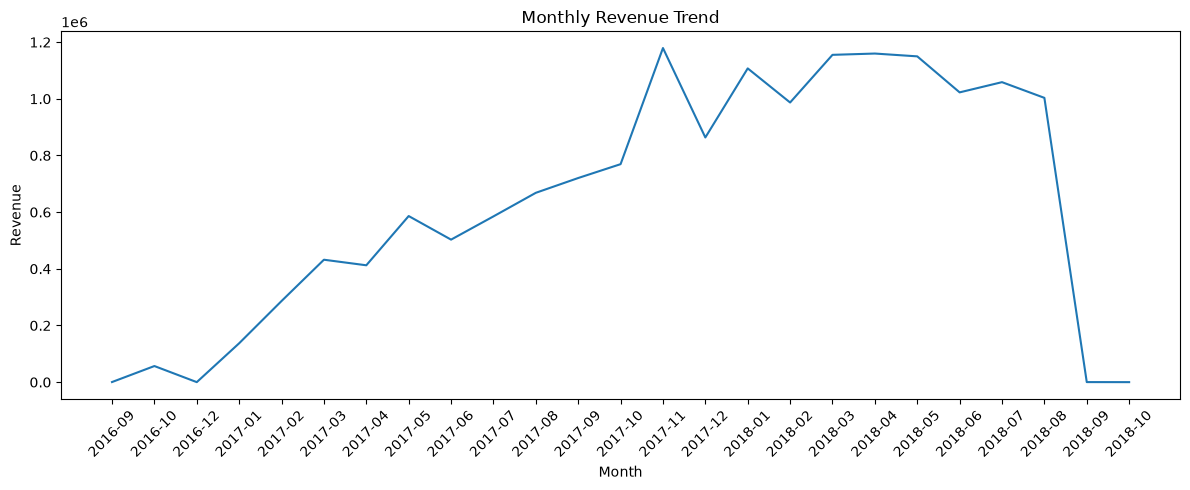

In [238]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_year_month"].astype(str),
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

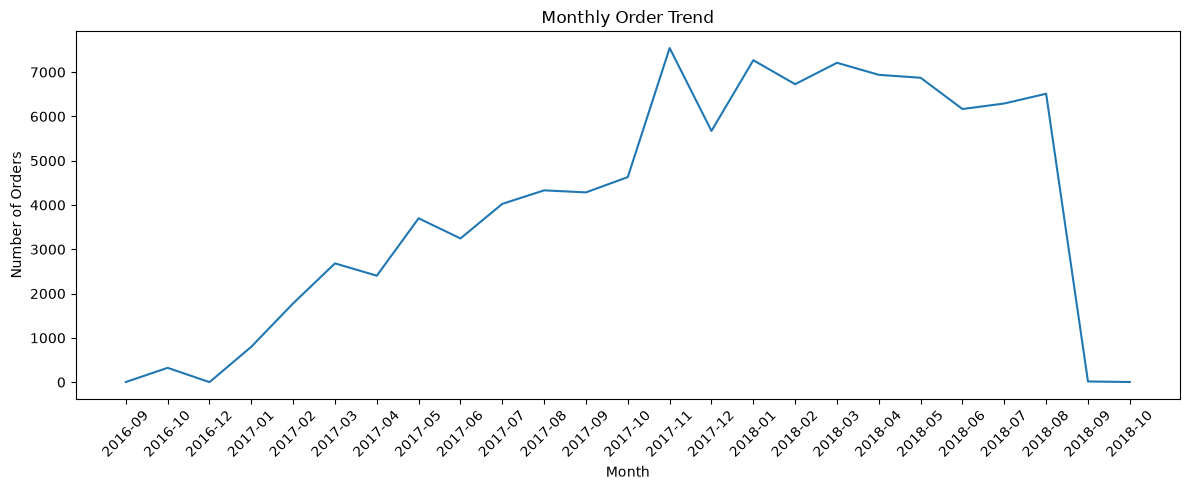

In [239]:
# Monthly Orders
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_year_month"].astype(str),
    monthly_sales["orders"]
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [240]:
#  Revenue & Orders by State
# ==========================================
# STATE-LEVEL SALES ANALYSIS
# ==========================================

state_sales = (
    final_data
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        revenue=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

state_sales["revenue"] = state_sales["revenue"].round(2)
state_sales["average_order_value"] = (
    state_sales["average_order_value"].round(2)
)

state_sales.head(10)

,customer_state,orders,customers,revenue,average_order_value
25,SP,41746,40302,5921678.12,141.85
18,RJ,12852,12384,2129681.98,165.71
10,MG,11635,11259,1856161.49,159.53
22,RS,5466,5277,885826.76,162.06
17,PR,5045,4882,800935.44,158.76
4,BA,3380,3277,611506.67,180.92
23,SC,3637,3534,610213.60,167.78
6,DF,2140,2075,353229.44,165.06
8,GO,2020,1952,347706.93,172.13
7,ES,2033,1964,324801.91,159.76


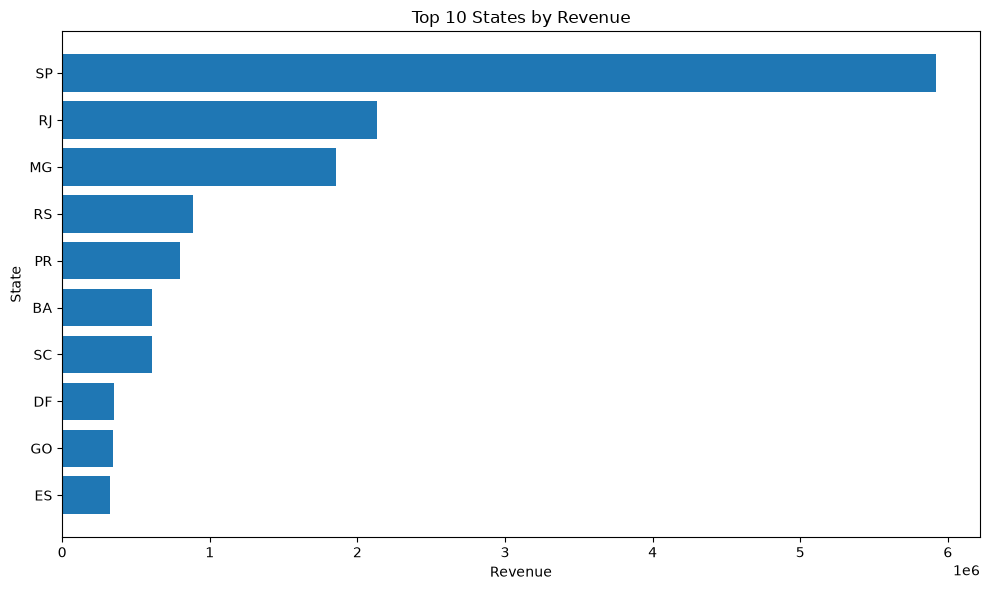

In [241]:
# Revenue by State Visualization
# ==========================================
# TOP 10 STATES BY REVENUE
# ==========================================

top_states = state_sales.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_states["customer_state"],
    top_states["revenue"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Revenue")
plt.ylabel("State")

plt.tight_layout()
plt.show()

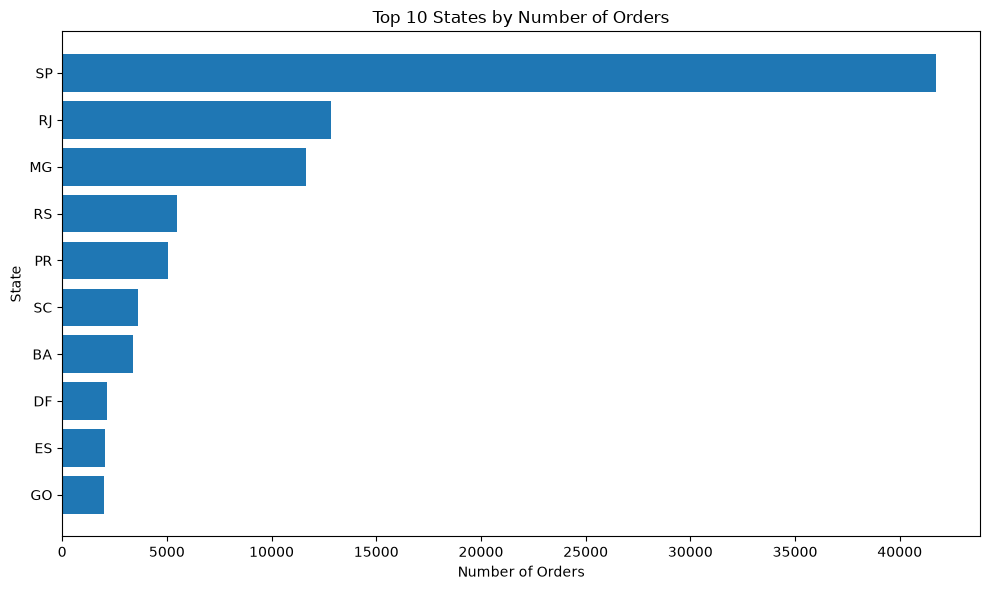

In [242]:
# orders by states
# ==========================================
# TOP 10 STATES BY ORDERS
# ==========================================

top_order_states = (
    state_sales
    .sort_values("orders", ascending=False)
    .head(10)
    .sort_values("orders")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_order_states["customer_state"],
    top_order_states["orders"]
)

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [243]:
# One-Time vs Repeat Customers
# ==========================================
# CUSTOMER ORDER FREQUENCY
# ==========================================

customer_orders = (
    final_data
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_spent=("total_order_value", "sum")
    )
    .reset_index()
)

customer_orders.head()

,customer_unique_id,total_orders,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,196.89


In [244]:
# ==========================================
# CUSTOMER TYPE
# ==========================================

customer_orders["customer_type"] = (
    customer_orders["total_orders"]
    .apply(lambda x: "Repeat Customer" if x > 1 else "One-Time Customer")
)

customer_orders["customer_type"].value_counts()

customer_type
One-Time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64

In [245]:
# ==========================================
# CUSTOMER TYPE PERCENTAGE
# ==========================================

customer_type_percentage = (
    customer_orders["customer_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

customer_type_percentage

customer_type
One-Time Customer    96.88
Repeat Customer       3.12
Name: proportion, dtype: float64

In [246]:
# ==========================================
# SPENDING BY CUSTOMER TYPE
# ==========================================

customer_type_spending = (
    customer_orders
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        total_revenue=("total_spent", "sum"),
        average_customer_spend=("total_spent", "mean")
    )
    .reset_index()
)

customer_type_spending["total_revenue"] = (
    customer_type_spending["total_revenue"].round(2)
)

customer_type_spending["average_customer_spend"] = (
    customer_type_spending["average_customer_spend"].round(2)
)

customer_type_spending

,customer_type,customers,total_revenue,average_customer_spend
0,One-Time Customer,93099,14921510.75,160.28
1,Repeat Customer,2997,922042.49,307.66


In [247]:
# ==========================================
# TOP CUSTOMERS BY SPENDING
# ==========================================

top_customers = (
    customer_orders
    .sort_values("total_spent", ascending=False)
    .head(10)
)

top_customers

,customer_unique_id,total_orders,total_spent,customer_type
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,One-Time Customer
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,Repeat Customer
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,One-Time Customer
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,One-Time Customer
26205,459bef486812aa25204be022145caa62,1,6922.21,One-Time Customer
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,One-Time Customer
24121,4007669dec559734d6f53e029e360987,1,6081.54,One-Time Customer
35070,5d0a2980b292d049061542014e8960bf,1,4809.44,One-Time Customer
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,One-Time Customer
27441,48e1ac109decbb87765a3eade6854098,1,4681.78,One-Time Customer


In [248]:
# ==========================================
# TOP CUSTOMERS BY NUMBER OF ORDERS
# ==========================================

top_repeat_customers = (
    customer_orders
    .sort_values(
        ["total_orders", "total_spent"],
        ascending=[False, False]
    )
    .head(10)
)

top_repeat_customers

,customer_unique_id,total_orders,total_spent,customer_type
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17,902.04,Repeat Customer
23472,3e43e6105506432c953e165fb2acf44c,9,1172.67,Repeat Customer
76082,ca77025e7201e3b30c44b472ff346268,7,1122.72,Repeat Customer
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7,959.01,Repeat Customer
37797,6469f99c1f9dfae7733b25662e7f1782,7,758.83,Repeat Customer
82883,dc813062e0fc23409cd255f7f53c7074,6,1033.62,Repeat Customer
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,944.21,Repeat Customer
37585,63cfc61cee11cbe306bff5857d00bfe4,6,826.32,Repeat Customer
90451,f0e310a6839dce9de1638e0fe5ab282a,6,540.69,Repeat Customer
83540,de34b16117594161a6a89c50b289d35a,6,530.38,Repeat Customer


In [249]:
# ==========================================
# CUSTOMER ORDER FREQUENCY
# ==========================================

order_frequency = (
    customer_orders["total_orders"]
    .value_counts()
    .sort_index()
)

order_frequency

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [250]:
# ==========================================
# REPEAT CUSTOMER REVENUE CONTRIBUTION
# ==========================================

repeat_revenue = customer_orders.loc[
    customer_orders["customer_type"] == "Repeat Customer",
    "total_spent"
].sum()

total_customer_revenue = customer_orders["total_spent"].sum()

repeat_revenue_percentage = (
    repeat_revenue / total_customer_revenue * 100
)

print(f"Repeat Customer Revenue: {repeat_revenue:,.2f}")
print(f"Total Customer Revenue: {total_customer_revenue:,.2f}")
print(f"Repeat Customer Revenue Contribution: {repeat_revenue_percentage:.2f}%")

Repeat Customer Revenue: 922,042.49
Total Customer Revenue: 15,843,553.24
Repeat Customer Revenue Contribution: 5.82%


In [251]:
# ==========================================
# CUSTOMER SPENDING DISTRIBUTION
# ==========================================

customer_orders["total_spent"].describe()

count    96096.000000
mean       164.872141
std        227.938658
min          0.000000
25%         62.390000
50%        107.270000
75%        182.237500
max      13664.080000
Name: total_spent, dtype: float64

In [252]:
# ==========================================
# TOP 20 HIGH-VALUE CUSTOMERS
# ==========================================

customer_orders.nlargest(
    20,
    "total_spent"
)

,customer_unique_id,total_orders,total_spent,customer_type
3826,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,One-Time Customer
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,Repeat Customer
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,One-Time Customer
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,One-Time Customer
26205,459bef486812aa25204be022145caa62,1,6922.21,One-Time Customer
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,One-Time Customer
24121,4007669dec559734d6f53e029e360987,1,6081.54,One-Time Customer
35070,5d0a2980b292d049061542014e8960bf,1,4809.44,One-Time Customer
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,One-Time Customer
27441,48e1ac109decbb87765a3eade6854098,1,4681.78,One-Time Customer


In [253]:
# ==========================================
# ORDER SIZE ANALYSIS
# ==========================================

order_size_distribution = (
    final_data["total_items"]
    .value_counts()
    .sort_index()
)

order_size_distribution

total_items
0.0       775
1.0     88863
2.0      7516
3.0      1322
4.0       505
5.0       204
6.0       198
7.0        22
8.0         8
9.0         3
10.0        8
11.0        4
12.0        5
13.0        1
14.0        2
15.0        2
20.0        2
21.0        1
Name: count, dtype: int64

In [256]:
# ==========================================
# ORDER SIZE PERCENTAGE
# ==========================================

order_size_percentage = (
    final_data["total_items"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

order_size_percentage.sort_index()

total_items
0.0      0.779
1.0     89.363
2.0      7.558
3.0      1.329
4.0      0.508
5.0      0.205
6.0      0.199
7.0      0.022
8.0      0.008
9.0      0.003
10.0     0.008
11.0     0.004
12.0     0.005
13.0     0.001
14.0     0.002
15.0     0.002
20.0     0.002
21.0     0.001
Name: proportion, dtype: float64

In [257]:
# ==========================================
# ORDER SIZE VS ORDER VALUE
# ==========================================

order_size_value = (
    final_data
    .groupby("total_items")
    .agg(
        orders=("order_id", "nunique"),
        average_order_value=("total_order_value", "mean"),
        total_revenue=("total_order_value", "sum")
    )
    .reset_index()
    .sort_values("total_items")
)

order_size_value["average_order_value"] = (
    order_size_value["average_order_value"].round(2)
)

order_size_value["total_revenue"] = (
    order_size_value["total_revenue"].round(2)
)

order_size_value

,total_items,orders,average_order_value,total_revenue
0,0.0,775,0.00,0.00
1,1.0,88863,150.75,13395744.77
2,2.0,7516,212.31,1595700.71
3,3.0,1322,292.74,386996.59
4,4.0,505,391.66,197789.11
5,5.0,204,473.37,96566.55
6,6.0,198,531.52,105240.00
7,7.0,22,611.45,13451.98
8,8.0,8,2304.93,18439.40
9,9.0,3,1092.24,3276.72


In [258]:
# ==========================================
# TOP ORDER SIZES BY REVENUE
# ==========================================

order_size_value.sort_values(
    "total_revenue",
    ascending=False
).head(10)

,total_items,orders,average_order_value,total_revenue
1,1.0,88863,150.75,13395744.77
2,2.0,7516,212.31,1595700.71
3,3.0,1322,292.74,386996.59
4,4.0,505,391.66,197789.11
6,6.0,198,531.52,105240.00
5,5.0,204,473.37,96566.55
8,8.0,8,2304.93,18439.40
10,10.0,8,1687.46,13499.68
7,7.0,22,611.45,13451.98
16,20.0,2,2232.60,4465.20


In [259]:
# ==========================================
# MULTI-ITEM ORDER ANALYSIS
# ==========================================

multi_item_orders = final_data[
    final_data["total_items"] > 1
]

single_item_orders = final_data[
    final_data["total_items"] == 1
]

multi_item_revenue = multi_item_orders["total_order_value"].sum()

single_item_revenue = single_item_orders["total_order_value"].sum()

total_revenue = final_data["total_order_value"].sum()

print(f"Multi-item Orders: {len(multi_item_orders):,}")
print(f"Multi-item Order Revenue: {multi_item_revenue:,.2f}")
print(
    f"Multi-item Revenue Contribution: "
    f"{multi_item_revenue / total_revenue * 100:.2f}%"
)

print()

print(f"Single-item Orders: {len(single_item_orders):,}")
print(f"Single-item Order Revenue: {single_item_revenue:,.2f}")
print(
    f"Single-item Revenue Contribution: "
    f"{single_item_revenue / total_revenue * 100:.2f}%"
)

Multi-item Orders: 9,803
Multi-item Order Revenue: 2,447,808.47
Multi-item Revenue Contribution: 15.45%

Single-item Orders: 88,863
Single-item Order Revenue: 13,395,744.77
Single-item Revenue Contribution: 84.55%


In [260]:
# ==========================================
# PRODUCT CATEGORY SALES ANALYSIS
# ==========================================

category_sales = (
    items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        items_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
    .reset_index()
)

category_sales["revenue"] = category_sales["revenue"].round(2)
category_sales["freight"] = category_sales["freight"].round(2)

category_sales = category_sales.sort_values(
    "revenue",
    ascending=False
)

category_sales.head(10)


,product_category_name,items_sold,revenue,freight
11,beleza_saude,9670,1258681.34,182566.73
66,relogios_presentes,5991,1205005.68,100535.93
13,cama_mesa_banho,11115,1036988.68,204693.04
32,esporte_lazer,8641,988048.97,168607.51
44,informatica_acessorios,7827,911954.32,147318.08
54,moveis_decoracao,8334,729762.49,172749.30
26,cool_stuff,3796,635290.85,84039.10
73,utilidades_domesticas,6964,632248.66,146149.11
8,automotivo,4235,592720.11,92664.21
40,ferramentas_jardim,4347,485256.46,98962.75


In [261]:
# ==========================================
# CATEGORY REVENUE CONTRIBUTION
# ==========================================

total_product_revenue = category_sales["revenue"].sum()

category_sales["revenue_percentage"] = (
    category_sales["revenue"]
    / total_product_revenue
    * 100
).round(2)

category_sales.head(10)

,product_category_name,items_sold,revenue,freight,revenue_percentage
11,beleza_saude,9670,1258681.34,182566.73,9.26
66,relogios_presentes,5991,1205005.68,100535.93,8.87
13,cama_mesa_banho,11115,1036988.68,204693.04,7.63
32,esporte_lazer,8641,988048.97,168607.51,7.27
44,informatica_acessorios,7827,911954.32,147318.08,6.71
54,moveis_decoracao,8334,729762.49,172749.30,5.37
26,cool_stuff,3796,635290.85,84039.10,4.67
73,utilidades_domesticas,6964,632248.66,146149.11,4.65
8,automotivo,4235,592720.11,92664.21,4.36
40,ferramentas_jardim,4347,485256.46,98962.75,3.57


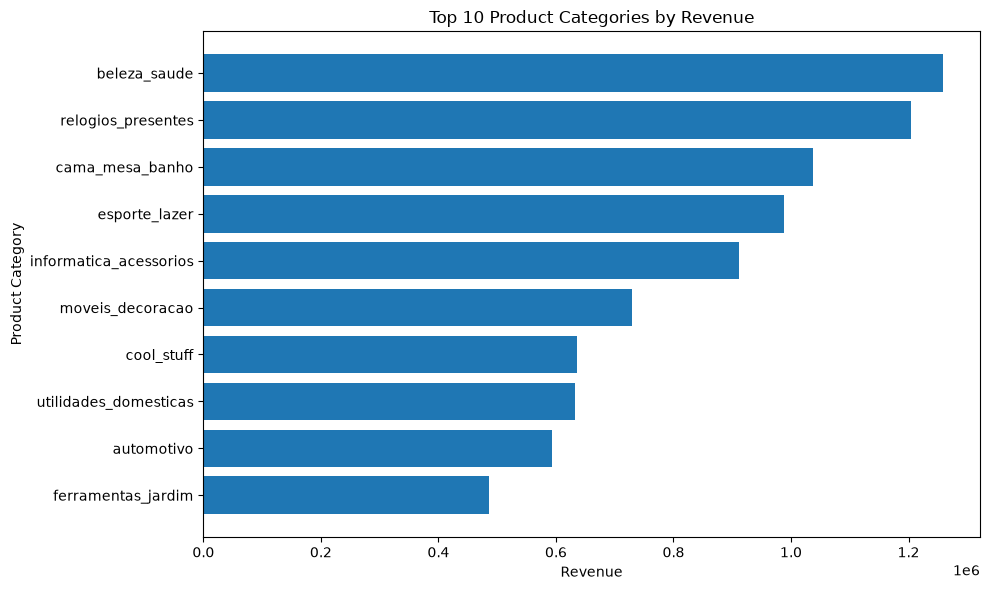

In [262]:
# ==========================================
# TOP 10 CATEGORIES BY REVENUE
# ==========================================

top_categories = (
    category_sales
    .head(10)
    .sort_values("revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["product_category_name"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

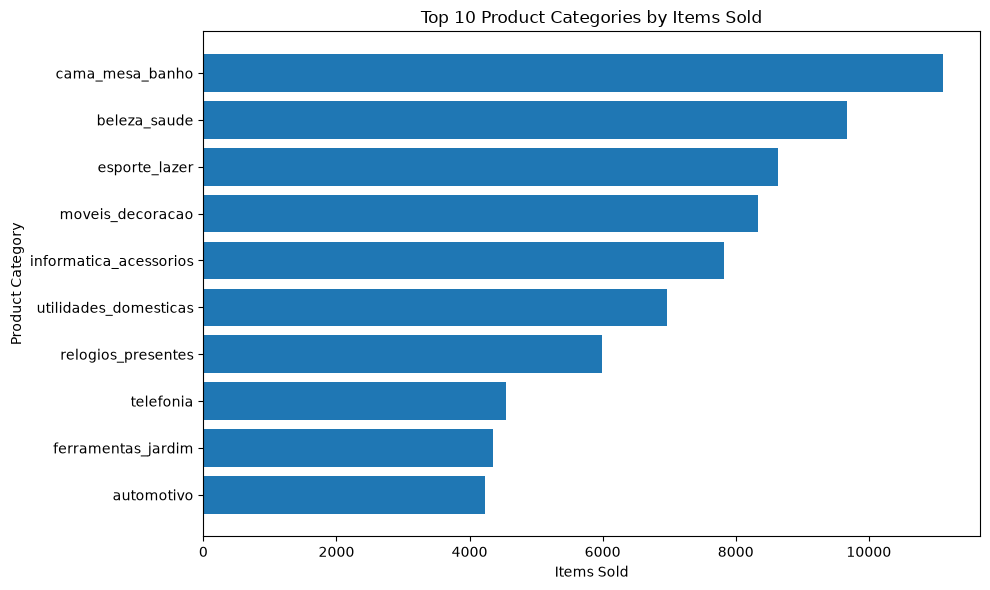

In [263]:
# ==========================================
# TOP 10 CATEGORIES BY ITEMS SOLD
# ==========================================

top_volume_categories = (
    category_sales
    .sort_values("items_sold", ascending=False)
    .head(10)
    .sort_values("items_sold")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_volume_categories["product_category_name"],
    top_volume_categories["items_sold"]
)

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Items Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [264]:
# ==========================================
# CATEGORY AVERAGE PRICE
# ==========================================

category_price = (
    items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        items_sold=("order_item_id", "count"),
        average_price=("price", "mean"),
        total_revenue=("price", "sum")
    )
    .reset_index()
)

category_price["average_price"] = (
    category_price["average_price"].round(2)
)

category_price["total_revenue"] = (
    category_price["total_revenue"].round(2)
)

category_price = category_price.sort_values(
    "average_price",
    ascending=False
)

category_price.head(10)

,product_category_name,items_sold,average_price,total_revenue
61,pcs,203,1098.34,222963.13
64,portateis_casa_forno_e_cafe,76,624.29,47445.71
29,eletrodomesticos_2,238,476.12,113317.74
0,agro_industria_e_comercio,212,342.12,72530.47
45,instrumentos_musicais,680,281.62,191498.88
31,eletroportateis,679,280.78,190648.58
65,portateis_cozinha_e_preparadores_de_alimentos,15,264.57,3968.53
71,telefonia_fixa,264,225.69,59583.00
25,construcao_ferramentas_seguranca,194,208.99,40544.52
66,relogios_presentes,5991,201.14,1205005.68


In [265]:
# ==========================================
# ADD ENGLISH PRODUCT CATEGORY NAME
# ==========================================

category_mapping = category[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].copy()

products = products.merge(
    category_mapping,
    on="product_category_name",
    how="left"
)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna("Unknown")
)

products[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head(10)

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [266]:
products[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].drop_duplicates().head(20)

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [268]:
# ==========================================
# PRODUCT CATEGORY SALES ANALYSIS
# ==========================================

category_sales = (
    items
    .merge(
        products[
            ["product_id", "product_category_name_english"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name_english")
    .agg(
        items_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
    .reset_index()
)

category_sales["product_category_name_english"] = (
    category_sales["product_category_name_english"]
    .fillna("Unknown")
)

category_sales["revenue"] = category_sales["revenue"].round(2)
category_sales["freight"] = category_sales["freight"].round(2)

category_sales = category_sales.sort_values(
    "revenue",
    ascending=False
)

category_sales.head(10)

,product_category_name_english,items_sold,revenue,freight
44,health_beauty,9670,1258681.34,182566.73
71,watches_gifts,5991,1205005.68,100535.93
8,bed_bath_table,11115,1036988.68,204693.04
66,sports_leisure,8641,988048.97,168607.51
16,computers_accessories,7827,911954.32,147318.08
40,furniture_decor,8334,729762.49,172749.30
21,cool_stuff,3796,635290.85,84039.10
50,housewares,6964,632248.66,146149.11
6,auto,4235,592720.11,92664.21
43,garden_tools,4347,485256.46,98962.75


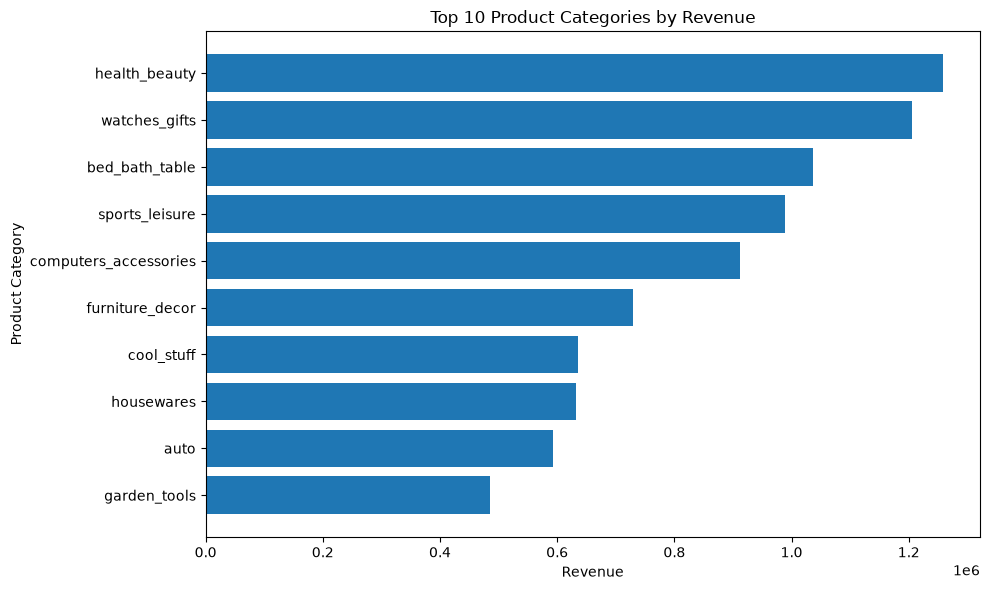

In [269]:
plt.figure(figsize=(10, 6))

top_categories = (
    category_sales
    .head(10)
    .sort_values("revenue")
)

plt.barh(
    top_categories["product_category_name_english"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()


In [270]:
# ==========================================
# ADD ENGLISH PRODUCT CATEGORY NAME
# ==========================================

category_mapping = category[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].copy()

products = products.merge(
    category_mapping,
    on="product_category_name",
    how="left"
)

products["product_category_name_english"] = (
    products["product_category_name_english"]
    .fillna("Unknown")
)

products[
    [
        "product_category_name",
        "product_category_name_english"
    ]
].head(10)

KeyError: 'product_category_name_english'

In [271]:
category.columns.tolist()

['product_category_name', 'product_category_name_english']

In [272]:
category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [273]:
# ============================================
# PRODUCT CATEGORY TRANSLATION
# ============================================

category_map = (
    category
    .set_index("product_category_name")["product_category_name_english"]
    .to_dict()
)

products["product_category_english"] = (
    products["product_category_name"]
    .map(category_map)
)

# Handle categories that could not be translated
products["product_category_english"] = (
    products["product_category_english"]
    .fillna("Unknown")
)

products[[
    "product_category_name",
    "product_category_english"
]].head(10)

,product_category_name,product_category_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [274]:
products["product_category_clean"] = (
    products["product_category_english"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

products[[
    "product_category_name",
    "product_category_english",
    "product_category_clean"
]].head(20)

,product_category_name,product_category_english,product_category_clean
0,perfumaria,perfumery,Perfumery
1,artes,art,Art
2,esporte_lazer,sports_leisure,Sports Leisure
3,bebes,baby,Baby
4,utilidades_domesticas,housewares,Housewares
5,instrumentos_musicais,musical_instruments,Musical Instruments
6,cool_stuff,cool_stuff,Cool Stuff
7,moveis_decoracao,furniture_decor,Furniture Decor
8,eletrodomesticos,home_appliances,Home Appliances
9,brinquedos,toys,Toys


In [275]:
products["product_category_clean"].isnull().sum()

np.int64(0)

In [276]:
products["product_category_clean"].value_counts().head(20)

product_category_clean
Bed Bath Table                     3029
Sports Leisure                     2867
Furniture Decor                    2657
Health Beauty                      2444
Housewares                         2335
Auto                               1900
Computers Accessories              1639
Toys                               1411
Watches Gifts                      1329
Telephony                          1134
Baby                                919
Perfumery                           868
Stationery                          849
Fashion Bags Accessories            849
Cool Stuff                          789
Garden Tools                        753
Pet Shop                            719
Unknown                             623
Electronics                         517
Construction Tools Construction     400
Name: count, dtype: int64

In [277]:
# ============================================
# PRODUCT CATEGORY + ORDER ITEMS
# ============================================

items_category = items.merge(
    products[
        ["product_id", "product_category_clean"]
    ],
    on="product_id",
    how="left"
)

items_category.shape

(112650, 9)

In [278]:
items_category["product_category_clean"].isnull().sum()

np.int64(0)

In [279]:
# ============================================
# CATEGORY PERFORMANCE SUMMARY
# ============================================

category_summary = (
    items_category
    .groupby("product_category_clean")
    .agg(
        total_units=("order_item_id", "count"),
        total_orders=("order_id", "nunique"),
        total_product_revenue=("price", "sum"),
        total_freight=("freight_value", "sum"),
        unique_products=("product_id", "nunique"),
        average_unit_price=("price", "mean")
    )
    .reset_index()
)

category_summary["total_revenue"] = (
    category_summary["total_product_revenue"] +
    category_summary["total_freight"]
)

category_summary["average_unit_price"] = (
    category_summary["average_unit_price"].round(2)
)

category_summary["total_product_revenue"] = (
    category_summary["total_product_revenue"].round(2)
)

category_summary["total_freight"] = (
    category_summary["total_freight"].round(2)
)

category_summary["total_revenue"] = (
    category_summary["total_revenue"].round(2)
)

category_summary.head()

,product_category_clean,total_units,total_orders,total_product_revenue,total_freight,unique_products,average_unit_price,total_revenue
0,Agro Industry And Commerce,212,182,72530.47,5843.60,74,342.12,78374.07
1,Air Conditioning,297,253,55024.96,6749.23,124,185.27,61774.19
2,Art,209,202,24202.64,4045.17,55,115.80,28247.81
3,Arts And Craftmanship,24,23,1814.01,370.13,19,75.58,2184.14
4,Audio,364,350,50688.50,5710.44,58,139.25,56398.94


In [280]:
category_summary.shape

(72, 8)

In [281]:
category_summary.sort_values(
    "total_revenue",
    ascending=False
).head(10)

,product_category_clean,total_units,total_orders,total_product_revenue,total_freight,unique_products,average_unit_price,total_revenue
43,Health Beauty,9670,8836,1258681.34,182566.73,2444,130.16,1441248.07
71,Watches Gifts,5991,5624,1205005.68,100535.93,1329,201.14,1305541.61
7,Bed Bath Table,11115,9417,1036988.68,204693.04,3029,93.30,1241681.72
65,Sports Leisure,8641,7720,988048.97,168607.51,2867,114.34,1156656.48
15,Computers Accessories,7827,6689,911954.32,147318.08,1639,116.51,1059272.40
39,Furniture Decor,8334,6449,729762.49,172749.30,2657,87.56,902511.79
49,Housewares,6964,5884,632248.66,146149.11,2335,90.79,778397.77
20,Cool Stuff,3796,3632,635290.85,84039.10,789,167.36,719329.95
5,Auto,4235,3897,592720.11,92664.21,1900,139.96,685384.32
42,Garden Tools,4347,3518,485256.46,98962.75,753,111.63,584219.21


In [282]:
category_summary["revenue_percentage"] = (
    category_summary["total_revenue"] /
    category_summary["total_revenue"].sum() * 100
).round(2)

category_summary.sort_values(
    "revenue_percentage",
    ascending=False
).head(10)

,product_category_clean,total_units,total_orders,total_product_revenue,total_freight,unique_products,average_unit_price,total_revenue,revenue_percentage
43,Health Beauty,9670,8836,1258681.34,182566.73,2444,130.16,1441248.07,9.10
71,Watches Gifts,5991,5624,1205005.68,100535.93,1329,201.14,1305541.61,8.24
7,Bed Bath Table,11115,9417,1036988.68,204693.04,3029,93.30,1241681.72,7.84
65,Sports Leisure,8641,7720,988048.97,168607.51,2867,114.34,1156656.48,7.30
15,Computers Accessories,7827,6689,911954.32,147318.08,1639,116.51,1059272.40,6.69
39,Furniture Decor,8334,6449,729762.49,172749.30,2657,87.56,902511.79,5.70
49,Housewares,6964,5884,632248.66,146149.11,2335,90.79,778397.77,4.91
20,Cool Stuff,3796,3632,635290.85,84039.10,789,167.36,719329.95,4.54
5,Auto,4235,3897,592720.11,92664.21,1900,139.96,685384.32,4.33
42,Garden Tools,4347,3518,485256.46,98962.75,753,111.63,584219.21,3.69


In [283]:
category_summary.sort_values(
    "total_units",
    ascending=False
).head(10)

,product_category_clean,total_units,total_orders,total_product_revenue,total_freight,unique_products,average_unit_price,total_revenue,revenue_percentage
7,Bed Bath Table,11115,9417,1036988.68,204693.04,3029,93.30,1241681.72,7.84
43,Health Beauty,9670,8836,1258681.34,182566.73,2444,130.16,1441248.07,9.10
65,Sports Leisure,8641,7720,988048.97,168607.51,2867,114.34,1156656.48,7.30
39,Furniture Decor,8334,6449,729762.49,172749.30,2657,87.56,902511.79,5.70
15,Computers Accessories,7827,6689,911954.32,147318.08,1639,116.51,1059272.40,6.69
49,Housewares,6964,5884,632248.66,146149.11,2335,90.79,778397.77,4.91
71,Watches Gifts,5991,5624,1205005.68,100535.93,1329,201.14,1305541.61,8.24
68,Telephony,4545,4199,323667.53,71215.79,1134,71.21,394883.32,2.49
42,Garden Tools,4347,3518,485256.46,98962.75,753,111.63,584219.21,3.69
5,Auto,4235,3897,592720.11,92664.21,1900,139.96,685384.32,4.33


In [284]:
category_summary.sort_values(
    "average_unit_price",
    ascending=False
).head(10)

,product_category_clean,total_units,total_orders,total_product_revenue,total_freight,unique_products,average_unit_price,total_revenue,revenue_percentage
14,Computers,203,181,222963.13,9836.30,30,1098.34,232799.43,1.47
64,Small Appliances Home Oven And Coffee,76,75,47445.71,2747.86,31,624.29,50193.57,0.32
45,Home Appliances 2,238,234,113317.74,10600.18,90,476.12,123917.92,0.78
0,Agro Industry And Commerce,212,182,72530.47,5843.60,74,342.12,78374.07,0.49
56,Musical Instruments,680,628,191498.88,18638.49,289,281.62,210137.37,1.33
63,Small Appliances,679,630,190648.58,16020.25,231,280.78,206668.83,1.30
34,Fixed Telephony,264,217,59583.00,4637.81,116,225.69,64220.81,0.41
19,Construction Tools Safety,194,167,40544.52,3919.10,91,208.99,44463.62,0.28
71,Watches Gifts,5991,5624,1205005.68,100535.93,1329,201.14,1305541.61,8.24
1,Air Conditioning,297,253,55024.96,6749.23,124,185.27,61774.19,0.39


In [285]:
# ============================================
# SELLER PERFORMANCE SUMMARY
# ============================================

seller_summary = (
    items
    .groupby("seller_id")
    .agg(
        total_units=("order_item_id", "count"),
        total_orders=("order_id", "nunique"),
        total_product_revenue=("price", "sum"),
        total_freight=("freight_value", "sum"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

seller_summary["total_revenue"] = (
    seller_summary["total_product_revenue"] +
    seller_summary["total_freight"]
)

seller_summary["average_order_value"] = (
    seller_summary["total_revenue"] /
    seller_summary["total_orders"]
)

seller_summary = seller_summary.round(2)

seller_summary.head()


,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,63.06,1,2748.06,916.02
1,001cca7ae9ae17fb1caed9dfb1094831,239,200,25080.03,8854.14,11,33934.17,169.67
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00,17.94,1,267.94,267.94
3,002100f778ceb8431b7a1020ff7ab48f,55,51,1234.50,793.66,24,2028.16,39.77
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00,19.38,1,139.38,139.38


In [286]:
seller_summary.shape

(3095, 8)

In [287]:
seller_summary.isnull().sum()

seller_id                0
total_units              0
total_orders             0
total_product_revenue    0
total_freight            0
unique_products          0
total_revenue            0
average_order_value      0
dtype: int64

In [288]:
seller_summary.sort_values(
    "total_revenue",
    ascending=False
).head(10)

,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,229472.63,20168.07,95,249640.70,220.53
1535,7c67e1448b00f6e969d365cea6b010ab,1364,982,187923.89,51612.55,198,239536.44,243.93
1013,53243585a1d6dc2643021fd1853d8905,410,358,222776.05,13080.63,23,235856.68,658.82
881,4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92,35067.04,399,235539.96,130.42
3024,fa1c13f2614d7b5c4749cbc52fecda94,586,585,194042.03,10042.70,289,204084.73,348.86
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57,24955.75,222,185192.32,140.94
1560,7e93a43ef30c4f03f38b393420bc753a,340,336,176431.87,6322.18,186,182754.05,543.91
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,138968.55,33892.14,154,172860.69,188.92
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53,20902.85,149,162648.38,140.21
1824,955fee9216a65b617aa5c0531780ce60,1499,1287,135171.70,25430.98,104,160602.68,124.79


In [289]:
seller_summary.sort_values(
    "total_units",
    ascending=False
).head(10)

,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value
1235,6560211a19b47992c3666cc44a7e94c0,2033,1854,123304.83,27960.94,256,151265.77,81.59
881,4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92,35067.04,399,235539.96,130.42
368,1f50f920176fa81dab994f9023523100,1931,1404,106939.21,35165.77,23,142104.98,101.21
2481,cc419e0650a3c5ba77189a1882b7556a,1775,1706,104288.42,25668.99,37,129957.41,76.18
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57,24955.75,222,185192.32,140.94
1824,955fee9216a65b617aa5c0531780ce60,1499,1287,135171.70,25430.98,104,160602.68,124.79
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,138968.55,33892.14,154,172860.69,188.92
1535,7c67e1448b00f6e969d365cea6b010ab,1364,982,187923.89,51612.55,198,239536.44,243.93
2836,ea8482cd71df3c1969d7b9473ff13abc,1203,1146,37177.52,17544.77,220,54722.29,47.75
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53,20902.85,149,162648.38,140.21


In [290]:
seller_summary.sort_values(
    "total_orders",
    ascending=False
).head(10)


,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value
1235,6560211a19b47992c3666cc44a7e94c0,2033,1854,123304.83,27960.94,256,151265.77,81.59
881,4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92,35067.04,399,235539.96,130.42
2481,cc419e0650a3c5ba77189a1882b7556a,1775,1706,104288.42,25668.99,37,129957.41,76.18
368,1f50f920176fa81dab994f9023523100,1931,1404,106939.21,35165.77,23,142104.98,101.21
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57,24955.75,222,185192.32,140.94
1824,955fee9216a65b617aa5c0531780ce60,1499,1287,135171.70,25430.98,104,160602.68,124.79
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53,20902.85,149,162648.38,140.21
2836,ea8482cd71df3c1969d7b9473ff13abc,1203,1146,37177.52,17544.77,220,54722.29,47.75
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,229472.63,20168.07,95,249640.70,220.53
731,3d871de0142ce09b7081e2b9d1733cb1,1147,1080,94914.20,22433.51,202,117347.71,108.66


In [291]:
seller_summary["revenue_percentage"] = (
    seller_summary["total_revenue"] /
    seller_summary["total_revenue"].sum() * 100
).round(2)

seller_summary.sort_values(
    "revenue_percentage",
    ascending=False
).head(10)

,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value,revenue_percentage
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,229472.63,20168.07,95,249640.70,220.53,1.58
1535,7c67e1448b00f6e969d365cea6b010ab,1364,982,187923.89,51612.55,198,239536.44,243.93,1.51
881,4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92,35067.04,399,235539.96,130.42,1.49
1013,53243585a1d6dc2643021fd1853d8905,410,358,222776.05,13080.63,23,235856.68,658.82,1.49
3024,fa1c13f2614d7b5c4749cbc52fecda94,586,585,194042.03,10042.70,289,204084.73,348.86,1.29
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57,24955.75,222,185192.32,140.94,1.17
1560,7e93a43ef30c4f03f38b393420bc753a,340,336,176431.87,6322.18,186,182754.05,543.91,1.15
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,138968.55,33892.14,154,172860.69,188.92,1.09
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53,20902.85,149,162648.38,140.21,1.03
1824,955fee9216a65b617aa5c0531780ce60,1499,1287,135171.70,25430.98,104,160602.68,124.79,1.01


In [292]:
seller_summary.sort_values(
    "average_order_value",
    ascending=False
).head(10)

,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value,revenue_percentage
1583,80ceebb4ee9b31afb6c6a916a574a1e2,1,1,6729.00,193.21,1,6922.21,6922.21,0.04
2881,ee27a8f15b1dded4d213a468ba4eb391,1,1,6499.00,227.66,1,6726.66,6726.66,0.04
2157,b37c4c02bda3161a7546a4e6d222d5b2,15,4,24075.00,412.60,3,24487.60,6121.90,0.15
1078,585175ec331ea177fa47199e39a6170a,1,1,3549.00,53.47,1,3602.47,3602.47,0.02
2073,abe021b01ba992245271b9aa422032df,2,2,6720.00,117.24,2,6837.24,3418.62,0.04
1943,a00824eb9093d40e589b940ec45c4eb0,3,3,9399.97,379.49,1,9779.46,3259.82,0.06
2730,e2a1ac9bf33e5549a2a4f834e70df2f8,5,5,14999.45,201.11,1,15200.56,3040.11,0.10
2813,e908c0f3646e8b60375734a350d95d71,1,1,2951.00,58.53,1,3009.53,3009.53,0.02
2589,d63c73efd41eb002280e7ec831424edb,2,2,5598.00,168.59,2,5766.59,2883.30,0.04
238,1444c08e64d55fb3c25f0f09c07ffcf2,1,1,2749.00,69.74,1,2818.74,2818.74,0.02


In [293]:
seller_summary[
    seller_summary["total_orders"] >= 10
].sort_values(
    "average_order_value",
    ascending=False
).head(10)

,seller_id,total_units,total_orders,total_product_revenue,total_freight,unique_products,total_revenue,average_order_value,revenue_percentage
1086,59417c56835dd8e2e72f91f809cd4092,18,18,36459.00,1198.77,9,37657.77,2092.10,0.24
774,40db9e9aa57f7bb151bcda6b0f9bdbb7,12,12,23168.00,655.99,9,23823.99,1985.33,0.15
518,2bf6a2c1e71bbd29a4ad64e6d3c3629f,31,30,50628.90,1000.59,28,51629.49,1720.98,0.33
2364,c3acdfac4e3e97ff87529454fbc03642,12,12,16788.00,269.28,9,17057.28,1421.44,0.11
2136,b1b3948701c5c72445495bd161b83a4c,18,18,24699.19,486.30,4,25185.49,1399.19,0.16
2209,b839e41795b7f3ad94cc2014a52f6796,36,33,42829.00,920.93,10,43749.93,1325.76,0.28
2903,f08a5b9dd6767129688d001acafc21e5,18,11,14069.63,496.11,7,14565.74,1324.16,0.09
1660,87b740daf17b5d1be335a64164ec6842,13,13,14699.87,1482.51,9,16182.38,1244.80,0.10
2237,ba90964cff9b9e0e6f32b23b82465f7b,38,38,44212.50,1311.00,11,45523.50,1197.99,0.29
3085,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,20,20,21940.80,1754.40,13,23695.20,1184.76,0.15


In [294]:
top_10_seller_revenue = (
    seller_summary
    .nlargest(10, "total_revenue")["total_revenue"]
    .sum()
)

total_seller_revenue = seller_summary["total_revenue"].sum()

top_10_seller_percentage = (
    top_10_seller_revenue /
    total_seller_revenue * 100
)

round(top_10_seller_percentage, 2)

np.float64(12.8)

In [295]:
# ============================================
# CUSTOMER STATE PERFORMANCE
# ============================================

state_summary = (
    final_data
    .groupby("customer_state")
    .agg(
        customers=("customer_unique_id", "nunique"),
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        average_order_value=("total_order_value", "mean"),
        total_items=("total_items", "sum")
    )
    .reset_index()
)

state_summary["total_revenue"] = (
    state_summary["total_revenue"].round(2)
)

state_summary["average_order_value"] = (
    state_summary["average_order_value"].round(2)
)

state_summary

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items
0,AC,77,81,19669.70,242.84,92.0
1,AL,401,413,96229.40,233.00,444.0
2,AM,143,148,27835.73,188.08,165.0
3,AP,67,68,16262.80,239.16,82.0
4,BA,3277,3380,611506.67,180.92,3799.0
5,CE,1313,1336,275606.30,206.29,1478.0
6,DF,2075,2140,353229.44,165.06,2406.0
7,ES,1964,2033,324801.91,159.76,2256.0
8,GO,1952,2020,347706.93,172.13,2333.0
9,MA,726,747,151171.99,202.37,824.0


In [296]:
state_summary.shape

(27, 6)

In [297]:
state_summary.sort_values(
    "customers",
    ascending=False
).head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items
25,SP,40302,41746,5921678.12,141.85,47449.0
18,RJ,12384,12852,2129681.98,165.71,14579.0
10,MG,11259,11635,1856161.49,159.53,13129.0
22,RS,5277,5466,885826.76,162.06,6235.0
17,PR,4882,5045,800935.44,158.76,5740.0
23,SC,3534,3637,610213.60,167.78,4176.0
4,BA,3277,3380,611506.67,180.92,3799.0
6,DF,2075,2140,353229.44,165.06,2406.0
7,ES,1964,2033,324801.91,159.76,2256.0
8,GO,1952,2020,347706.93,172.13,2333.0


In [298]:
state_summary.sort_values(
    "total_revenue",
    ascending=False
).head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items
25,SP,40302,41746,5921678.12,141.85,47449.0
18,RJ,12384,12852,2129681.98,165.71,14579.0
10,MG,11259,11635,1856161.49,159.53,13129.0
22,RS,5277,5466,885826.76,162.06,6235.0
17,PR,4882,5045,800935.44,158.76,5740.0
4,BA,3277,3380,611506.67,180.92,3799.0
23,SC,3534,3637,610213.60,167.78,4176.0
6,DF,2075,2140,353229.44,165.06,2406.0
8,GO,1952,2020,347706.93,172.13,2333.0
7,ES,1964,2033,324801.91,159.76,2256.0


In [299]:
state_summary["revenue_percentage"] = (
    state_summary["total_revenue"] /
    state_summary["total_revenue"].sum() * 100
).round(2)

state_summary.sort_values(
    "revenue_percentage",
    ascending=False
).head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items,revenue_percentage
25,SP,40302,41746,5921678.12,141.85,47449.0,37.38
18,RJ,12384,12852,2129681.98,165.71,14579.0,13.44
10,MG,11259,11635,1856161.49,159.53,13129.0,11.72
22,RS,5277,5466,885826.76,162.06,6235.0,5.59
17,PR,4882,5045,800935.44,158.76,5740.0,5.06
4,BA,3277,3380,611506.67,180.92,3799.0,3.86
23,SC,3534,3637,610213.60,167.78,4176.0,3.85
6,DF,2075,2140,353229.44,165.06,2406.0,2.23
8,GO,1952,2020,347706.93,172.13,2333.0,2.19
7,ES,1964,2033,324801.91,159.76,2256.0,2.05


In [300]:
state_summary.sort_values(
    "average_order_value",
    ascending=False
).head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items,revenue_percentage
14,PB,519,536,140987.81,263.04,602.0,0.89
0,AC,77,81,19669.70,242.84,92.0,0.12
3,AP,67,68,16262.80,239.16,82.0,0.10
1,AL,401,413,96229.40,233.00,444.0,0.61
20,RO,240,253,57558.02,227.50,278.0,0.36
13,PA,949,975,217647.11,223.23,1080.0,1.37
26,TO,273,280,61354.42,219.12,315.0,0.39
21,RR,45,46,10064.62,218.80,52.0,0.06
16,PI,482,495,108132.28,218.45,542.0,0.68
19,RN,474,485,101895.08,210.09,529.0,0.64


In [301]:
state_summary["revenue_per_customer"] = (
    state_summary["total_revenue"] /
    state_summary["customers"]
).round(2)

state_summary.sort_values(
    "revenue_per_customer",
    ascending=False
).head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items,revenue_percentage,revenue_per_customer
14,PB,519,536,140987.81,263.04,602.0,0.89,271.65
0,AC,77,81,19669.70,242.84,92.0,0.12,255.45
3,AP,67,68,16262.80,239.16,82.0,0.10,242.73
1,AL,401,413,96229.40,233.00,444.0,0.61,239.97
20,RO,240,253,57558.02,227.50,278.0,0.36,239.83
13,PA,949,975,217647.11,223.23,1080.0,1.37,229.34
26,TO,273,280,61354.42,219.12,315.0,0.39,224.74
16,PI,482,495,108132.28,218.45,542.0,0.68,224.34
21,RR,45,46,10064.62,218.80,52.0,0.06,223.66
19,RN,474,485,101895.08,210.09,529.0,0.64,214.97


In [302]:
state_summary.isnull().sum()

customer_state          0
customers               0
total_orders            0
total_revenue           0
average_order_value     0
total_items             0
revenue_percentage      0
revenue_per_customer    0
dtype: int64

In [303]:
# ============================================
# YEARLY SALES PERFORMANCE
# ============================================

yearly_sales = (
    final_data
    .groupby("order_year")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        total_items=("total_items", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .reset_index()
)

yearly_sales["total_revenue"] = yearly_sales["total_revenue"].round(2)
yearly_sales["average_order_value"] = yearly_sales["average_order_value"].round(2)

yearly_sales

,order_year,total_orders,total_revenue,total_items,average_order_value
0,2016,329,57183.21,370.0,173.81
1,2017,45101,7142672.43,50864.0,158.37
2,2018,54011,8643697.60,61416.0,160.04


In [304]:
# ============================================
# MONTHLY SALES PERFORMANCE
# ============================================

monthly_sales = (
    final_data
    .groupby(["order_year", "order_month"])
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        total_items=("total_items", "sum")
    )
    .reset_index()
)

monthly_sales["total_revenue"] = monthly_sales["total_revenue"].round(2)

monthly_sales

,order_year,order_month,total_orders,total_revenue,total_items
0,2016,9,4,354.75,6.0
1,2016,10,324,56808.84,363.0
2,2016,12,1,19.62,1.0
3,2017,1,800,137188.49,955.0
4,2017,2,1780,286280.62,1951.0
5,2017,3,2682,432048.59,3000.0
6,2017,4,2404,412422.24,2684.0
7,2017,5,3700,586190.95,4136.0
8,2017,6,3245,502963.04,3583.0
9,2017,7,4026,584971.62,4519.0


In [305]:
monthly_sales.sort_values(
    "total_revenue",
    ascending=False
).head(10)

,order_year,order_month,total_orders,total_revenue,total_items
13,2017,11,7544,1179143.77,8665.0
18,2018,4,6939,1159698.04,7975.0
17,2018,3,7211,1155126.82,8217.0
19,2018,5,6873,1149781.82,7925.0
15,2018,1,7269,1107301.89,8208.0
21,2018,7,6292,1058728.03,7092.0
20,2018,6,6167,1022677.11,7078.0
22,2018,8,6512,1003308.47,7248.0
16,2018,2,6728,986908.96,7672.0
14,2017,12,5673,863547.23,6308.0


In [306]:
month_summary = (
    final_data
    .groupby("order_month_name")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        total_items=("total_items", "sum")
    )
    .reset_index()
)

month_summary["total_revenue"] = (
    month_summary["total_revenue"].round(2)
)

month_summary

,order_month_name,total_orders,total_revenue,total_items
0,April,9343,1572120.28,10659.0
1,August,10843,1671513.07,12158.0
2,December,5674,863566.85,6309.0
3,February,8508,1273189.58,9623.0
4,January,8069,1244490.38,9163.0
5,July,10318,1643699.65,11611.0
6,June,9412,1525640.15,10661.0
7,March,9893,1587175.41,11217.0
8,May,10573,1735972.77,12061.0
9,November,7544,1179143.77,8665.0


In [307]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

month_summary["order_month_name"] = pd.Categorical(
    month_summary["order_month_name"],
    categories=month_order,
    ordered=True
)

month_summary = month_summary.sort_values(
    "order_month_name"
)

month_summary

,order_month_name,total_orders,total_revenue,total_items
4,January,8069,1244490.38,9163.0
3,February,8508,1273189.58,9623.0
7,March,9893,1587175.41,11217.0
0,April,9343,1572120.28,10659.0
8,May,10573,1735972.77,12061.0
6,June,9412,1525640.15,10661.0
5,July,10318,1643699.65,11611.0
1,August,10843,1671513.07,12158.0
11,September,4305,720920.12,4838.0
10,October,4959,826121.21,5685.0


In [308]:
# ============================================
# DAY OF WEEK PERFORMANCE
# ============================================

day_summary = (
    final_data
    .groupby(["order_day_number", "order_day_name"])
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        total_items=("total_items", "sum")
    )
    .reset_index()
)

day_summary["total_revenue"] = (
    day_summary["total_revenue"].round(2)
)

day_summary = day_summary.sort_values(
    "order_day_number"
)

day_summary

,order_day_number,order_day_name,total_orders,total_revenue,total_items
0,0,Monday,16196,2600533.82,18393.0
1,1,Tuesday,15963,2532228.11,18237.0
2,2,Wednesday,15552,2466682.13,17600.0
3,3,Thursday,14761,2351584.20,16797.0
4,4,Friday,14122,2281931.02,16039.0
5,5,Saturday,10887,1752075.49,12168.0
6,6,Sunday,11960,1858518.47,13416.0


In [309]:
weekend_summary = (
    final_data
    .groupby("is_weekend")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        total_items=("total_items", "sum"),
        average_order_value=("total_order_value", "mean")
    )
    .reset_index()
)

weekend_summary["day_type"] = (
    weekend_summary["is_weekend"]
    .map({
        0: "Weekday",
        1: "Weekend"
    })
)

weekend_summary["total_revenue"] = (
    weekend_summary["total_revenue"].round(2)
)

weekend_summary["average_order_value"] = (
    weekend_summary["average_order_value"].round(2)
)

weekend_summary

,is_weekend,total_orders,total_revenue,total_items,average_order_value,day_type
0,0,76594,12232959.28,87066.0,159.71,Weekday
1,1,22847,3610593.96,25584.0,158.03,Weekend


In [310]:
# ============================================
# HOURLY SALES PERFORMANCE
# ============================================

hourly_sales = (
    final_data
    .groupby("order_hour")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        total_items=("total_items", "sum")
    )
    .reset_index()
)

hourly_sales["total_revenue"] = (
    hourly_sales["total_revenue"].round(2)
)

hourly_sales

,order_hour,total_orders,total_revenue,total_items
0,0,2394,371018.90,2717.0
1,1,1170,174479.00,1289.0
2,2,510,65526.06,584.0
3,3,272,41319.89,314.0
4,4,206,28334.08,244.0
5,5,188,26175.23,218.0
6,6,502,67452.45,556.0
7,7,1231,179761.85,1377.0
8,8,2967,458449.50,3377.0
9,9,4785,790252.51,5449.0


In [311]:
hourly_sales.sort_values(
    "total_orders",
    ascending=False
).head(10)

,order_hour,total_orders,total_revenue,total_items
16,16,6675,1090233.44,7653.0
11,11,6578,1023074.93,7432.0
14,14,6569,1100743.07,7565.0
13,13,6518,1015875.62,7403.0
15,15,6454,1052986.78,7370.0
21,21,6217,975604.70,6920.0
20,20,6193,995339.27,6875.0
10,10,6177,975972.35,7034.0
17,17,6150,979469.54,7010.0
12,12,5995,986082.17,6819.0


In [312]:
print("Yearly Sales:", yearly_sales.shape)
print("Monthly Sales:", monthly_sales.shape)
print("Month Summary:", month_summary.shape)
print("Day Summary:", day_summary.shape)
print("Weekend Summary:", weekend_summary.shape)
print("Hourly Sales:", hourly_sales.shape)

Yearly Sales: (3, 5)
Monthly Sales: (25, 5)
Month Summary: (12, 4)
Day Summary: (7, 5)
Weekend Summary: (2, 6)
Hourly Sales: (24, 4)


In [313]:
# ============================================
# PAYMENT METHOD ANALYSIS
# ============================================

payment_method_summary = (
    payments
    .groupby("payment_type")
    .agg(
        total_transactions=("payment_sequential", "count"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean"),
        unique_orders=("order_id", "nunique")
    )
    .reset_index()
)

payment_method_summary["total_payment_value"] = (
    payment_method_summary["total_payment_value"].round(2)
)

payment_method_summary["average_payment_value"] = (
    payment_method_summary["average_payment_value"].round(2)
)

payment_method_summary.sort_values(
    "total_payment_value",
    ascending=False
)

,payment_type,total_transactions,total_payment_value,average_payment_value,unique_orders
1,credit_card,76795,12542084.19,163.32,76505
0,boleto,19784,2869361.27,145.03,19784
4,voucher,5775,379436.87,65.70,3866
2,debit_card,1529,217989.79,142.57,1528
3,not_defined,3,0.00,0.00,3


In [314]:
# ============================================
# PAYMENT METHOD DISTRIBUTION
# ============================================

payment_method_summary["transaction_percentage"] = (
    payment_method_summary["total_transactions"] /
    payment_method_summary["total_transactions"].sum()
    * 100
).round(2)

payment_method_summary.sort_values(
    "transaction_percentage",
    ascending=False
)

,payment_type,total_transactions,total_payment_value,average_payment_value,unique_orders,transaction_percentage
1,credit_card,76795,12542084.19,163.32,76505,73.92
0,boleto,19784,2869361.27,145.03,19784,19.04
4,voucher,5775,379436.87,65.70,3866,5.56
2,debit_card,1529,217989.79,142.57,1528,1.47
3,not_defined,3,0.00,0.00,3,0.00


In [315]:
# ============================================
# PAYMENT REVENUE CONTRIBUTION
# ============================================

payment_method_summary["revenue_percentage"] = (
    payment_method_summary["total_payment_value"] /
    payment_method_summary["total_payment_value"].sum()
    * 100
).round(2)

payment_method_summary.sort_values(
    "revenue_percentage",
    ascending=False
)

,payment_type,total_transactions,total_payment_value,average_payment_value,unique_orders,transaction_percentage,revenue_percentage
1,credit_card,76795,12542084.19,163.32,76505,73.92,78.34
0,boleto,19784,2869361.27,145.03,19784,19.04,17.92
4,voucher,5775,379436.87,65.70,3866,5.56,2.37
2,debit_card,1529,217989.79,142.57,1528,1.47,1.36
3,not_defined,3,0.00,0.00,3,0.00,0.00


In [316]:
# ============================================
# INSTALLMENT ANALYSIS
# ============================================

installment_summary = (
    payments
    .groupby("payment_installments")
    .agg(
        transactions=("payment_sequential", "count"),
        total_payment_value=("payment_value", "sum"),
        average_payment_value=("payment_value", "mean")
    )
    .reset_index()
    .sort_values("payment_installments")
)

installment_summary["total_payment_value"] = (
    installment_summary["total_payment_value"].round(2)
)

installment_summary["average_payment_value"] = (
    installment_summary["average_payment_value"].round(2)
)

installment_summary.head(20)

,payment_installments,transactions,total_payment_value,average_payment_value
0,0,2,188.63,94.32
1,1,52546,5907233.36,112.42
2,2,12413,1579283.03,127.23
3,3,10461,1491103.80,142.54
4,4,7098,1163907.61,163.98
5,5,5239,961174.30,183.47
6,6,3920,822611.81,209.85
7,7,1626,305157.39,187.67
8,8,4268,1313423.34,307.74
9,9,644,131015.92,203.44


In [317]:
payments["payment_installments"].value_counts().sort_index().head(20)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
Name: count, dtype: int64

In [318]:
# ============================================
# INSTALLMENTS VS PAYMENT VALUE
# ============================================

installment_value = (
    payments
    .groupby("payment_installments")
    .agg(
        transactions=("order_id", "count"),
        average_payment=("payment_value", "mean"),
        total_payment=("payment_value", "sum")
    )
    .reset_index()
)

installment_value["average_payment"] = (
    installment_value["average_payment"].round(2)
)

installment_value["total_payment"] = (
    installment_value["total_payment"].round(2)
)

installment_value.sort_values(
    "average_payment",
    ascending=False
).head(15)

,payment_installments,transactions,average_payment,total_payment
19,20,17,615.80,10468.63
23,24,18,610.05,10980.88
18,18,27,486.48,13135.05
15,15,74,445.55,32970.93
10,10,5328,415.09,2211577.34
12,12,133,321.68,42783.24
8,8,4268,307.74,1313423.34
16,16,5,292.69,1463.47
20,21,3,243.70,731.10
22,23,1,236.48,236.48


In [319]:
# ============================================
# CREDIT CARD INSTALLMENT ANALYSIS
# ============================================

credit_card = payments[
    payments["payment_type"] == "credit_card"
]

credit_card["payment_installments"].describe()

count    76795.000000
mean         3.507155
std          2.850990
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         24.000000
Name: payment_installments, dtype: float64

In [320]:
credit_card_installments = (
    credit_card["payment_installments"]
    .value_counts()
    .sort_index()
)

credit_card_installments

payment_installments
0         2
1     25455
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

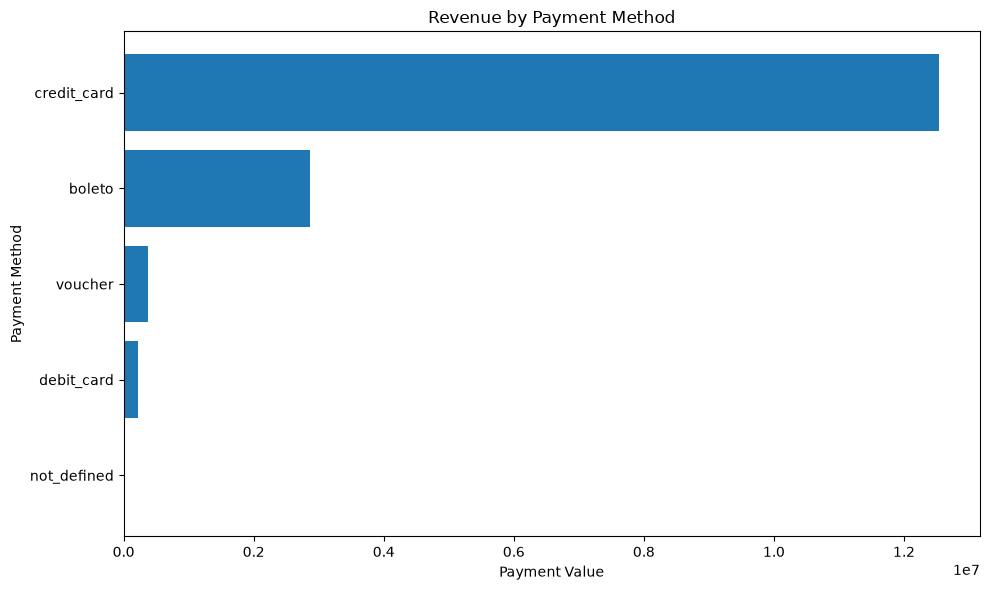

In [321]:
plt.figure(figsize=(10, 6))

payment_plot = payment_method_summary.sort_values(
    "total_payment_value"
)

plt.barh(
    payment_plot["payment_type"],
    payment_plot["total_payment_value"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Value")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

In [322]:
print("Payment method summary:", payment_method_summary.shape)
print("Installment summary:", installment_summary.shape)
print("Credit card transactions:", len(credit_card))
print("Payment methods:", payments["payment_type"].nunique())

Payment method summary: (5, 7)
Installment summary: (24, 4)
Credit card transactions: 76795
Payment methods: 5


In [323]:
delivery_summary = (
    final_data
    .groupby("delivery_performance")
    .agg(
        total_orders=("order_id", "nunique"),
        average_delivery_days=("delivery_time_days", "mean"),
        average_delay_days=("delivery_delay_days", "mean"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delivery_summary["average_delivery_days"] = (
    delivery_summary["average_delivery_days"].round(2)
)

delivery_summary["average_delay_days"] = (
    delivery_summary["average_delay_days"].round(2)
)

delivery_summary["average_review_score"] = (
    delivery_summary["average_review_score"].round(2)
)

delivery_summary

,delivery_performance,total_orders,average_delivery_days,average_delay_days,average_review_score
0,Early,88649,10.88,-13.01,4.29
1,Late,7827,31.52,9.55,2.57
2,Not Delivered,2965,NaN,NaN,1.75


In [324]:
review_score_summary = (
    final_data
    .dropna(subset=["review_score"])
    .groupby("review_score")
    .agg(
        total_reviews=("order_id", "nunique")
    )
    .reset_index()
)

review_score_summary["percentage"] = (
    review_score_summary["total_reviews"] /
    review_score_summary["total_reviews"].sum()
    * 100
).round(2)

review_score_summary

,review_score,total_reviews,percentage
0,1.000000,11316,11.47
1,1.500000,8,0.01
2,2.000000,3125,3.17
3,2.500000,34,0.03
4,3.000000,8136,8.25
5,3.333333,1,0.00
6,3.500000,25,0.03
7,4.000000,19018,19.27
8,4.333333,1,0.00
9,4.500000,54,0.05


In [326]:
delivery_review = (
    final_data
    .dropna(subset=["review_score"])
    .groupby("delivery_performance")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delivery_review["average_review_score"] = (
    delivery_review["average_review_score"].round(2)
)

delivery_review

,delivery_performance,orders,average_review_score
0,Early,88168,4.29
1,Late,7662,2.57
2,Not Delivered,2843,1.75


In [327]:
state_delivery = (
    final_data
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("delivery_performance", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

state_delivery["late_delivery_rate"] = (
    state_delivery["late_orders"] /
    state_delivery["total_orders"]
    * 100
).round(2)

state_delivery = (
    state_delivery
    .query("total_orders >= 100")
    .sort_values("late_delivery_rate", ascending=False)
)

state_delivery.head(10)

,customer_state,total_orders,late_orders,late_delivery_rate
1,AL,413,95,23.00
9,MA,747,141,18.88
16,PI,495,76,15.35
5,CE,1336,196,14.67
24,SE,350,51,14.57
4,BA,3380,457,13.52
18,RJ,12852,1664,12.95
26,TO,280,35,12.50
13,PA,975,117,12.00
7,ES,2033,244,12.00


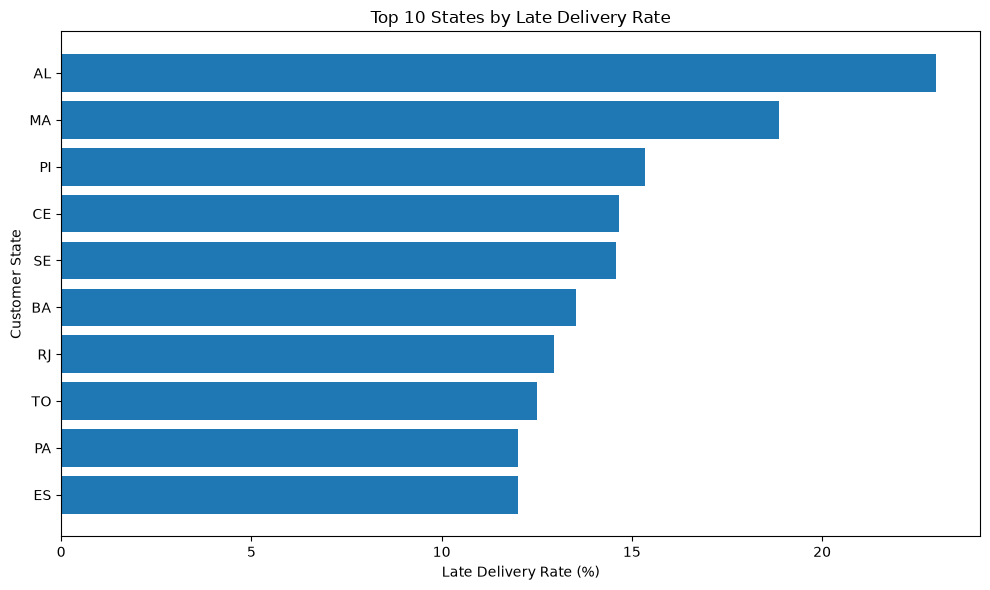

In [328]:
import matplotlib.pyplot as plt

top_late_states = state_delivery.head(10).sort_values(
    "late_delivery_rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_late_states["customer_state"],
    top_late_states["late_delivery_rate"]
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")
plt.title("Top 10 States by Late Delivery Rate")

plt.tight_layout()
plt.show()

In [329]:
late_review_analysis = (
    final_data
    .dropna(subset=["review_score"])
    .groupby("delivery_performance")
    .agg(
        total_reviews=("order_id", "nunique"),
        one_star_reviews=("review_score", lambda x: (x == 1).sum())
    )
    .reset_index()
)

late_review_analysis["one_star_rate"] = (
    late_review_analysis["one_star_reviews"] /
    late_review_analysis["total_reviews"]
    * 100
).round(2)

late_review_analysis

,delivery_performance,total_reviews,one_star_reviews,one_star_rate
0,Early,88168,5783,6.56
1,Late,7662,3533,46.11
2,Not Delivered,2843,2000,70.35


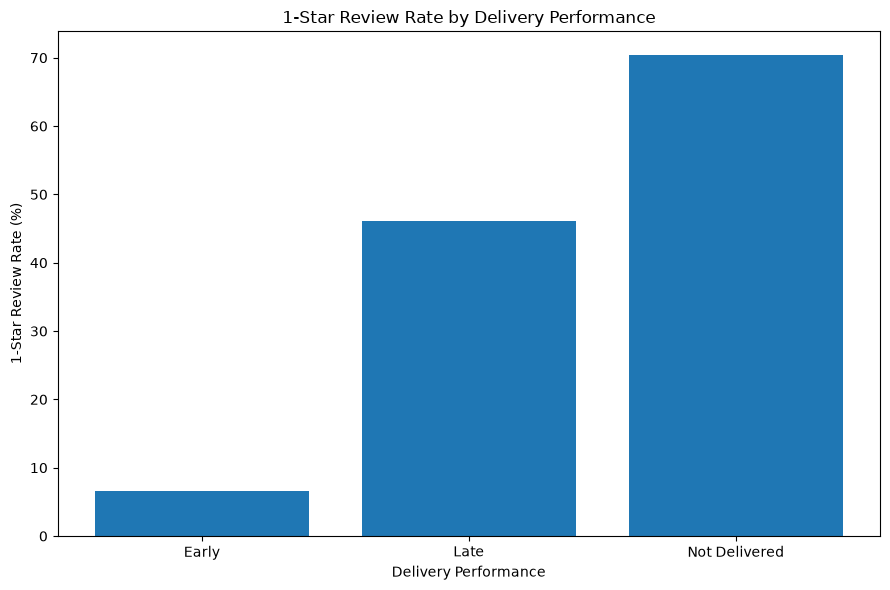

In [330]:
plt.figure(figsize=(9, 6))

plt.bar(
    late_review_analysis["delivery_performance"],
    late_review_analysis["one_star_rate"]
)

plt.xlabel("Delivery Performance")
plt.ylabel("1-Star Review Rate (%)")
plt.title("1-Star Review Rate by Delivery Performance")

plt.tight_layout()
plt.show()

In [331]:
state_delivery_time = (
    final_data
    .dropna(subset=["delivery_time_days"])
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        average_delivery_days=("delivery_time_days", "mean")
    )
    .reset_index()
)

state_delivery_time["average_delivery_days"] = (
    state_delivery_time["average_delivery_days"].round(2)
)

state_delivery_time = (
    state_delivery_time
    .query("total_orders >= 100")
    .sort_values("average_delivery_days", ascending=False)
)

state_delivery_time.head(10)

,customer_state,total_orders,average_delivery_days
2,AM,145,26.43
1,AL,397,24.54
13,PA,946,23.77
9,MA,717,21.57
24,SE,335,21.52
5,CE,1279,21.27
14,PB,517,20.43
16,PI,476,19.46
20,RO,243,19.37
4,BA,3256,19.34


In [332]:
final_data["delivery_time_category"] = pd.cut(
    final_data["delivery_time_days"],
    bins=[0, 7, 14, 21, 30, float("inf")],
    labels=[
        "0-7 Days",
        "8-14 Days",
        "15-21 Days",
        "22-30 Days",
        "30+ Days"
    ]
)

delivery_time_review = (
    final_data
    .dropna(subset=["delivery_time_category", "review_score"])
    .groupby("delivery_time_category", observed=True)
    .agg(
        total_orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean")
    )
    .reset_index()
)

delivery_time_review["average_review_score"] = (
    delivery_time_review["average_review_score"].round(2)
)

delivery_time_review

,delivery_time_category,total_orders,average_review_score
0,0-7 Days,25933,4.42
1,8-14 Days,40000,4.31
2,15-21 Days,17582,4.14
3,22-30 Days,7882,3.61
4,30+ Days,4433,2.25


In [333]:
customer_type_summary = (
    customer_orders
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "nunique"),
        total_orders=("total_orders", "sum"),
        total_revenue=("total_spent", "sum"),
        average_customer_spend=("total_spent", "mean")
    )
    .reset_index()
)

customer_type_summary["revenue_percentage"] = (
    customer_type_summary["total_revenue"] /
    customer_type_summary["total_revenue"].sum()
    * 100
).round(2)

customer_type_summary["average_customer_spend"] = (
    customer_type_summary["average_customer_spend"].round(2)
)

customer_type_summary["total_revenue"] = (
    customer_type_summary["total_revenue"].round(2)
)

customer_type_summary

,customer_type,customers,total_orders,total_revenue,average_customer_spend,revenue_percentage
0,One-Time Customer,93099,93099,14921510.75,160.28,94.18
1,Repeat Customer,2997,6342,922042.49,307.66,5.82


In [334]:
customer_orders["customer_segment"] = "One-Time / Low Value"

customer_orders.loc[
    (customer_orders["total_orders"] > 1) &
    (customer_orders["total_spent"] >= customer_orders["total_spent"].median()),
    "customer_segment"
] = "Repeat / High Value"

customer_orders.loc[
    (customer_orders["total_orders"] > 1) &
    (customer_orders["total_spent"] < customer_orders["total_spent"].median()),
    "customer_segment"
] = "Repeat / Low Value"

customer_orders.loc[
    (customer_orders["total_orders"] == 1) &
    (customer_orders["total_spent"] >= customer_orders["total_spent"].median()),
    "customer_segment"
] = "One-Time / High Value"

customer_segment_summary = (
    customer_orders
    .groupby("customer_segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        total_orders=("total_orders", "sum"),
        total_revenue=("total_spent", "sum"),
        average_customer_spend=("total_spent", "mean")
    )
    .reset_index()
)

customer_segment_summary["revenue_percentage"] = (
    customer_segment_summary["total_revenue"] /
    customer_segment_summary["total_revenue"].sum()
    * 100
).round(2)

customer_segment_summary["average_customer_spend"] = (
    customer_segment_summary["average_customer_spend"].round(2)
)

customer_segment_summary["total_revenue"] = (
    customer_segment_summary["total_revenue"].round(2)
)

customer_segment_summary


,customer_segment,customers,total_orders,total_revenue,average_customer_spend,revenue_percentage
0,One-Time / High Value,45455,45455,11953122.19,262.97,75.44
1,One-Time / Low Value,47644,47644,2968388.56,62.30,18.74
2,Repeat / High Value,2602,5539,890862.30,342.38,5.62
3,Repeat / Low Value,395,803,31180.19,78.94,0.20


In [335]:
retention_opportunity = customer_segment_summary[
    customer_segment_summary["customer_segment"] == "One-Time / High Value"
].copy()

retention_opportunity

,customer_segment,customers,total_orders,total_revenue,average_customer_spend,revenue_percentage
0,One-Time / High Value,45455,45455,11953122.19,262.97,75.44


In [336]:
category_opportunity = (
    category_summary[
        [
            "product_category_clean",
            "total_units",
            "total_orders",
            "total_revenue",
            "revenue_percentage",
            "average_unit_price"
        ]
    ]
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

category_opportunity.head(15)


,product_category_clean,total_units,total_orders,total_revenue,revenue_percentage,average_unit_price
0,Health Beauty,9670,8836,1441248.07,9.10,130.16
1,Watches Gifts,5991,5624,1305541.61,8.24,201.14
2,Bed Bath Table,11115,9417,1241681.72,7.84,93.30
3,Sports Leisure,8641,7720,1156656.48,7.30,114.34
4,Computers Accessories,7827,6689,1059272.40,6.69,116.51
5,Furniture Decor,8334,6449,902511.79,5.70,87.56
6,Housewares,6964,5884,778397.77,4.91,90.79
7,Cool Stuff,3796,3632,719329.95,4.54,167.36
8,Auto,4235,3897,685384.32,4.33,139.96
9,Garden Tools,4347,3518,584219.21,3.69,111.63


In [337]:
top_categories = category_summary.sort_values(
    "total_revenue",
    ascending=False
).reset_index(drop=True)

total_category_revenue = top_categories["total_revenue"].sum()

top_5_revenue = top_categories.head(5)["total_revenue"].sum()
top_10_revenue = top_categories.head(10)["total_revenue"].sum()

top_5_share = (top_5_revenue / total_category_revenue * 100).round(2)
top_10_share = (top_10_revenue / total_category_revenue * 100).round(2)

print("Top 5 Categories Revenue Share:", top_5_share, "%")
print("Top 10 Categories Revenue Share:", top_10_share, "%")

Top 5 Categories Revenue Share: 39.16 %
Top 10 Categories Revenue Share: 62.32 %


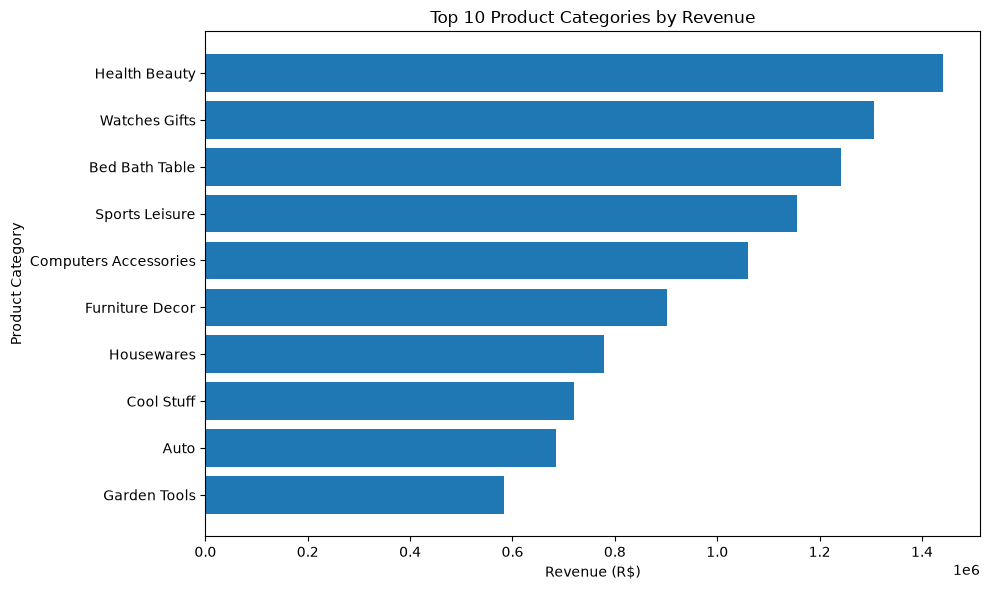

In [338]:
top_10_categories = (
    category_summary
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_categories["product_category_clean"],
    top_10_categories["total_revenue"]
)

plt.xlabel("Revenue (R$)")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

plt.tight_layout()
plt.show()

In [339]:
seller_opportunity = (
    seller_summary[
        [
            "seller_id",
            "total_units",
            "total_orders",
            "total_revenue",
            "average_order_value",
            "revenue_percentage"
        ]
    ]
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

seller_opportunity.head(10)

,seller_id,total_units,total_orders,total_revenue,average_order_value,revenue_percentage
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,249640.70,220.53,1.58
1,7c67e1448b00f6e969d365cea6b010ab,1364,982,239536.44,243.93,1.51
2,53243585a1d6dc2643021fd1853d8905,410,358,235856.68,658.82,1.49
3,4a3ca9315b744ce9f8e9374361493884,1987,1806,235539.96,130.42,1.49
4,fa1c13f2614d7b5c4749cbc52fecda94,586,585,204084.73,348.86,1.29
5,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,185192.32,140.94,1.17
6,7e93a43ef30c4f03f38b393420bc753a,340,336,182754.05,543.91,1.15
7,1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,172860.69,188.92,1.09
8,7a67c85e85bb2ce8582c35f2203ad736,1171,1160,162648.38,140.21,1.03
9,955fee9216a65b617aa5c0531780ce60,1499,1287,160602.68,124.79,1.01


In [340]:
top_sellers = (
    seller_summary
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

total_seller_revenue = top_sellers["total_revenue"].sum()

top_10_seller_revenue = (
    top_sellers.head(10)["total_revenue"].sum()
)

top_20_seller_revenue = (
    top_sellers.head(20)["total_revenue"].sum()
)

top_10_seller_share = (
    top_10_seller_revenue / total_seller_revenue * 100
).round(2)

top_20_seller_share = (
    top_20_seller_revenue / total_seller_revenue * 100
).round(2)

print("Top 10 Sellers Revenue Share:", top_10_seller_share, "%")
print("Top 20 Sellers Revenue Share:", top_20_seller_share, "%")

Top 10 Sellers Revenue Share: 12.8 %
Top 20 Sellers Revenue Share: 20.85 %


In [341]:
high_value_sellers = (
    seller_summary[
        seller_summary["total_orders"] >= 100
    ]
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

high_value_sellers[
    [
        "seller_id",
        "total_orders",
        "total_units",
        "total_revenue",
        "average_order_value"
    ]
].head(10)

,seller_id,total_orders,total_units,total_revenue,average_order_value
0,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,249640.70,220.53
1,7c67e1448b00f6e969d365cea6b010ab,982,1364,239536.44,243.93
2,53243585a1d6dc2643021fd1853d8905,358,410,235856.68,658.82
3,4a3ca9315b744ce9f8e9374361493884,1806,1987,235539.96,130.42
4,fa1c13f2614d7b5c4749cbc52fecda94,585,586,204084.73,348.86
5,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,185192.32,140.94
6,7e93a43ef30c4f03f38b393420bc753a,336,340,182754.05,543.91
7,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,172860.69,188.92
8,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,162648.38,140.21
9,955fee9216a65b617aa5c0531780ce60,1287,1499,160602.68,124.79


In [342]:
state_opportunity = (
    state_summary[
        [
            "customer_state",
            "customers",
            "total_orders",
            "total_revenue",
            "average_order_value",
            "revenue_per_customer"
        ]
    ]
    .query("customers >= 100")
    .sort_values("revenue_per_customer", ascending=False)
    .reset_index(drop=True)
)

state_opportunity.head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,revenue_per_customer
0,PB,519,536,140987.81,263.04,271.65
1,AL,401,413,96229.40,233.00,239.97
2,RO,240,253,57558.02,227.50,239.83
3,PA,949,975,217647.11,223.23,229.34
4,TO,273,280,61354.42,219.12,224.74
5,PI,482,495,108132.28,218.45,224.34
6,RN,474,485,101895.08,210.09,214.97
7,SE,342,350,73032.32,208.66,213.54
8,MT,876,907,186168.96,205.26,212.52
9,CE,1313,1336,275606.30,206.29,209.91


In [343]:
state_summary.sort_values(
    "total_revenue",
    ascending=False
).head(10)

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items,revenue_percentage,revenue_per_customer
25,SP,40302,41746,5921678.12,141.85,47449.0,37.38,146.93
18,RJ,12384,12852,2129681.98,165.71,14579.0,13.44,171.97
10,MG,11259,11635,1856161.49,159.53,13129.0,11.72,164.86
22,RS,5277,5466,885826.76,162.06,6235.0,5.59,167.87
17,PR,4882,5045,800935.44,158.76,5740.0,5.06,164.06
4,BA,3277,3380,611506.67,180.92,3799.0,3.86,186.61
23,SC,3534,3637,610213.60,167.78,4176.0,3.85,172.67
6,DF,2075,2140,353229.44,165.06,2406.0,2.23,170.23
8,GO,1952,2020,347706.93,172.13,2333.0,2.19,178.13
7,ES,1964,2033,324801.91,159.76,2256.0,2.05,165.38


In [344]:
top_states_revenue = (
    state_summary
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_states_revenue

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items,revenue_percentage,revenue_per_customer
0,SP,40302,41746,5921678.12,141.85,47449.0,37.38,146.93
1,RJ,12384,12852,2129681.98,165.71,14579.0,13.44,171.97
2,MG,11259,11635,1856161.49,159.53,13129.0,11.72,164.86
3,RS,5277,5466,885826.76,162.06,6235.0,5.59,167.87
4,PR,4882,5045,800935.44,158.76,5740.0,5.06,164.06
5,BA,3277,3380,611506.67,180.92,3799.0,3.86,186.61
6,SC,3534,3637,610213.60,167.78,4176.0,3.85,172.67
7,DF,2075,2140,353229.44,165.06,2406.0,2.23,170.23
8,GO,1952,2020,347706.93,172.13,2333.0,2.19,178.13
9,ES,1964,2033,324801.91,159.76,2256.0,2.05,165.38


In [345]:
top_states_orders = (
    state_summary
    .sort_values("total_orders", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_states_orders

,customer_state,customers,total_orders,total_revenue,average_order_value,total_items,revenue_percentage,revenue_per_customer
0,SP,40302,41746,5921678.12,141.85,47449.0,37.38,146.93
1,RJ,12384,12852,2129681.98,165.71,14579.0,13.44,171.97
2,MG,11259,11635,1856161.49,159.53,13129.0,11.72,164.86
3,RS,5277,5466,885826.76,162.06,6235.0,5.59,167.87
4,PR,4882,5045,800935.44,158.76,5740.0,5.06,164.06
5,SC,3534,3637,610213.60,167.78,4176.0,3.85,172.67
6,BA,3277,3380,611506.67,180.92,3799.0,3.86,186.61
7,DF,2075,2140,353229.44,165.06,2406.0,2.23,170.23
8,ES,1964,2033,324801.91,159.76,2256.0,2.05,165.38
9,GO,1952,2020,347706.93,172.13,2333.0,2.19,178.13


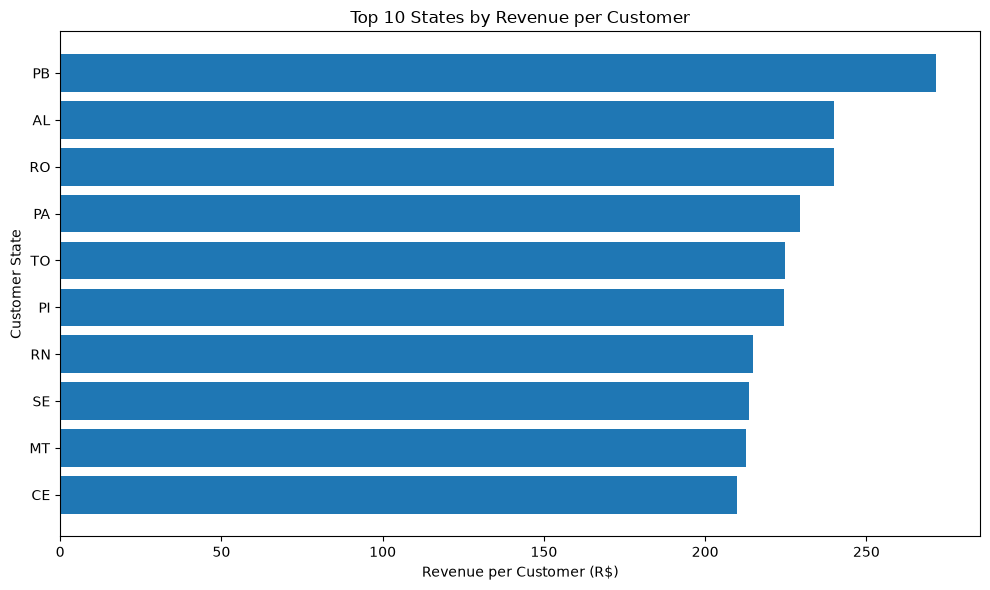

In [346]:
top_revenue_per_customer = (
    state_opportunity
    .head(10)
    .sort_values("revenue_per_customer")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue_per_customer["customer_state"],
    top_revenue_per_customer["revenue_per_customer"]
)

plt.xlabel("Revenue per Customer (R$)")
plt.ylabel("Customer State")
plt.title("Top 10 States by Revenue per Customer")

plt.tight_layout()
plt.show()

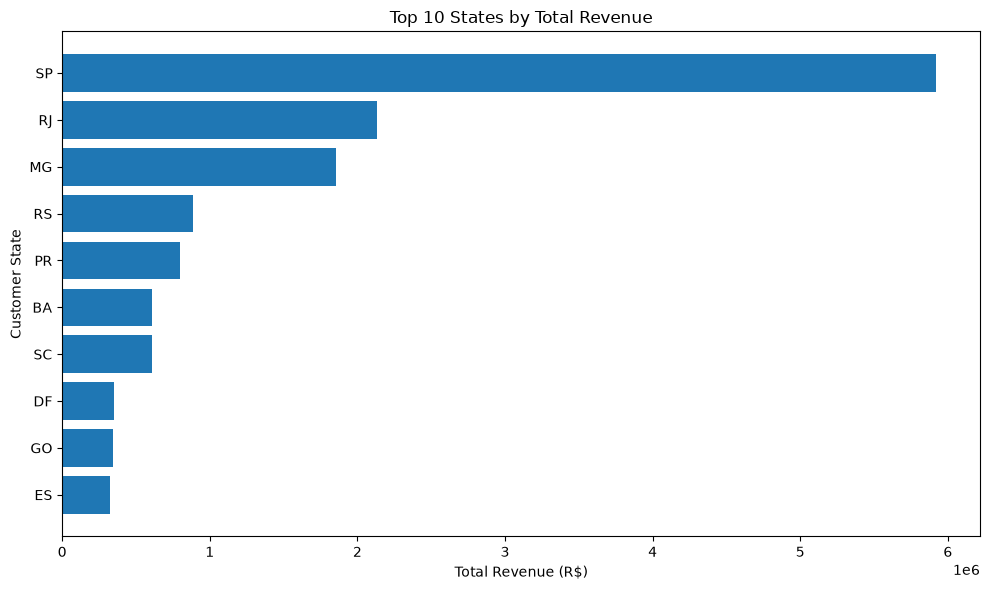

In [347]:
top_states_chart = (
    state_summary
    .sort_values("total_revenue")
    .tail(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_states_chart["customer_state"],
    top_states_chart["total_revenue"]
)

plt.xlabel("Total Revenue (R$)")
plt.ylabel("Customer State")
plt.title("Top 10 States by Total Revenue")

plt.tight_layout()
plt.show()

In [348]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Total Customers",
        "Total Revenue",
        "Average Order Value",
        "Total Items Sold",
        "Average Review Score",
        "Late Delivery Rate",
        "Repeat Customer Rate"
    ],
    "Value": [
        final_data["order_id"].nunique(),
        final_data["customer_unique_id"].nunique(),
        final_data["total_order_value"].sum(),
        final_data["total_order_value"].mean(),
        final_data["total_items"].sum(),
        final_data["review_score"].mean(),
        (final_data["delivery_performance"].eq("Late").sum()
         / final_data["order_id"].nunique() * 100),
        (customer_orders["customer_type"].eq("Repeat Customer").sum()
         / customer_orders["customer_unique_id"].nunique() * 100)
    ]
})

executive_kpis

,KPI,Value
0,Total Orders,9.944100e+04
1,Total Customers,9.609600e+04
2,Total Revenue,1.584355e+07
3,Average Order Value,1.593262e+02
4,Total Items Sold,1.126500e+05
5,Average Review Score,4.086793e+00
6,Late Delivery Rate,7.870999e+00
7,Repeat Customer Rate,3.118756e+00


In [349]:
executive_kpis.loc[
    executive_kpis["KPI"].isin([
        "Total Revenue",
        "Average Order Value"
    ]),
    "Value"
] = executive_kpis.loc[
    executive_kpis["KPI"].isin([
        "Total Revenue",
        "Average Order Value"
    ]),
    "Value"
].round(2)

executive_kpis.loc[
    executive_kpis["KPI"].isin([
        "Average Review Score",
        "Late Delivery Rate",
        "Repeat Customer Rate"
    ]),
    "Value"
] = executive_kpis.loc[
    executive_kpis["KPI"].isin([
        "Average Review Score",
        "Late Delivery Rate",
        "Repeat Customer Rate"
    ]),
    "Value"
].round(2)

executive_kpis

,KPI,Value
0,Total Orders,99441.00
1,Total Customers,96096.00
2,Total Revenue,15843553.24
3,Average Order Value,159.33
4,Total Items Sold,112650.00
5,Average Review Score,4.09
6,Late Delivery Rate,7.87
7,Repeat Customer Rate,3.12


In [350]:
business_opportunities = pd.DataFrame({
    "Area": [
        "Customer Retention",
        "Delivery Performance",
        "Customer Satisfaction",
        "Product Categories",
        "Seller Network",
        "Geographic Expansion"
    ],
    "Finding": [
        "Repeat customers are a small share of the customer base but spend more per customer.",
        "Late deliveries have a much lower average review score than early deliveries.",
        "Not-delivered orders have the highest 1-star review rate.",
        "Top 10 categories generate 62.32% of category revenue.",
        "Top 10 sellers generate only 12.80% of seller revenue.",
        "Some states have high revenue per customer while others have higher delivery times."
    ],
    "Recommendation": [
        "Convert high-value one-time customers into repeat customers.",
        "Improve logistics and delivery performance in high-delay regions.",
        "Prioritize prevention and resolution of undelivered orders.",
        "Maintain inventory and marketing focus on high-performing categories.",
        "Continue supporting top sellers while maintaining seller diversification.",
        "Use regional performance to guide targeted marketing and logistics investment."
    ]
})

business_opportunities

,Area,Finding,Recommendation
0,Customer Retention,Repeat customers are a small share of the cust...,Convert high-value one-time customers into rep...
1,Delivery Performance,Late deliveries have a much lower average revi...,Improve logistics and delivery performance in ...
2,Customer Satisfaction,Not-delivered orders have the highest 1-star r...,Prioritize prevention and resolution of undeli...
3,Product Categories,Top 10 categories generate 62.32% of category ...,Maintain inventory and marketing focus on high...
4,Seller Network,Top 10 sellers generate only 12.80% of seller ...,Continue supporting top sellers while maintain...
5,Geographic Expansion,Some states have high revenue per customer whi...,Use regional performance to guide targeted mar...


In [351]:
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print("\n1. CUSTOMER RETENTION")
print("Repeat customers spend substantially more per customer than one-time customers.")

print("\n2. DELIVERY PERFORMANCE")
print("Late deliveries are strongly associated with lower customer satisfaction.")

print("\n3. CUSTOMER SATISFACTION")
print("Undelivered orders have the highest 1-star review rate.")

print("\n4. PRODUCT CATEGORIES")
print("The top 10 categories contribute 62.32% of category revenue.")

print("\n5. SELLER NETWORK")
print("The top 10 sellers contribute only 12.80% of seller revenue.")

print("\n6. GEOGRAPHY")
print("Regional differences exist in revenue per customer and delivery performance.")

KEY BUSINESS INSIGHTS

1. CUSTOMER RETENTION
Repeat customers spend substantially more per customer than one-time customers.

2. DELIVERY PERFORMANCE
Late deliveries are strongly associated with lower customer satisfaction.

3. CUSTOMER SATISFACTION
Undelivered orders have the highest 1-star review rate.

4. PRODUCT CATEGORIES
The top 10 categories contribute 62.32% of category revenue.

5. SELLER NETWORK
The top 10 sellers contribute only 12.80% of seller revenue.

6. GEOGRAPHY
Regional differences exist in revenue per customer and delivery performance.


In [352]:
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print("\n1. CUSTOMER RETENTION")
print("Repeat customers spend substantially more per customer than one-time customers.")

print("\n2. DELIVERY PERFORMANCE")
print("Late deliveries are strongly associated with lower customer satisfaction.")

print("\n3. CUSTOMER SATISFACTION")
print("Undelivered orders have the highest 1-star review rate.")

print("\n4. PRODUCT CATEGORIES")
print("The top 10 categories contribute 62.32% of category revenue.")

print("\n5. SELLER NETWORK")
print("The top 10 sellers contribute only 12.80% of seller revenue.")

print("\n6. GEOGRAPHY")
print("Regional differences exist in revenue per customer and delivery performance.")

KEY BUSINESS INSIGHTS

1. CUSTOMER RETENTION
Repeat customers spend substantially more per customer than one-time customers.

2. DELIVERY PERFORMANCE
Late deliveries are strongly associated with lower customer satisfaction.

3. CUSTOMER SATISFACTION
Undelivered orders have the highest 1-star review rate.

4. PRODUCT CATEGORIES
The top 10 categories contribute 62.32% of category revenue.

5. SELLER NETWORK
The top 10 sellers contribute only 12.80% of seller revenue.

6. GEOGRAPHY
Regional differences exist in revenue per customer and delivery performance.


In [353]:
final_data[
    [
        "order_id",
        "customer_unique_id",
        "customer_state",
        "order_status",
        "total_order_value",
        "total_items",
        "total_payment_value",
        "review_score",
        "delivery_time_days",
        "delivery_delay_days",
        "delivery_performance"
    ]
].head()

,order_id,customer_unique_id,customer_state,order_status,total_order_value,total_items,total_payment_value,review_score,delivery_time_days,delivery_delay_days,delivery_performance
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,38.71,1.0,38.71,4.0,8.436574,-7.107488,Early
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,delivered,141.46,1.0,141.46,4.0,13.782037,-5.355729,Early
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,179.12,1.0,179.12,5.0,9.394213,-17.245498,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,delivered,72.20,1.0,72.20,5.0,13.208750,-12.980069,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,delivered,28.62,1.0,28.62,5.0,2.873877,-9.238171,Early


In [354]:
final_data.to_csv(
    "olist_final_data.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [355]:
import os

file_size_mb = os.path.getsize("olist_final_data.csv") / (1024 * 1024)

print("File Size:", round(file_size_mb, 2), "MB")

File Size: 55.74 MB
